In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.region import Region
from pangal.plot import Point, Contours
from pangal.photometry_table import PhotometryTable

import warnings
warnings.simplefilter("ignore")


In [2]:
directory = '/home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/'


muse_file =  glob.glob(directory+'*muse*.fits')
spitzer_files = glob.glob(directory+'*SPITZER_*.fits')
sdss_files = glob.glob(directory+'*sdss*.fits')
wise_files = glob.glob(directory+'*WISE*.fits')
hershel_files = glob.glob(directory+'*hpacs*.fits')
twomass_files = glob.glob(directory+'*2mass*.fits')
hst_files = glob.glob(directory+'*hst*.fits')
galex_files = ['/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits','/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits']

files_list = galex_files + muse_file + sdss_files + twomass_files + spitzer_files + hershel_files +hst_files # + wise_files 



In [5]:
z_true =  0.023974 
ra_center, dec_center = 194.523241, 28.242570

distance = 104 # Mpc

M_star = 10**10.32
#V = Md_to_Vc(M_star)

#print(V)
#spin = 0.05
#print(Rd(V,spin))

# Convert angular scale to physical scale
from astropy.cosmology import Planck18 as cosmo
z_Coma = 0.023513
D_A = cosmo.angular_diameter_distance(z_Coma).to('pc').value

theta_deg_1kpc = 1e3 / D_A / (np.pi / 180)               # Convert 1 kpc in deg
theta_arcsec_1kpc = 1e3 / D_A / (np.pi / 648000)         # Convert 1 kpc in arcsec



In [6]:
galaxy = PanGal(fits_files=files_list,target_coords = [ra_center,dec_center],fov=1/12,) #EBmV=0.0093,EBmV_err=0.0002)


Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits
Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits
Processing MUSE:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/NGC4848_muse_cut.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_u.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_i.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_g.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_r.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_z.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_H.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_K.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848

In [7]:
galaxy.overview

Images: 

['galex_nuv', 'galex_fuv', 'muse_blue', 'muse_green', 'muse_red', 'muse_nir', 'muse_white_aoe', 'sdss_u', 'sdss_i', 'sdss_g', 'sdss_r', 'sdss_z', '2mass_h', '2mass_ks', '2mass_j', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 'spitzer_irac_1', 'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um', 'hst_wfc3_uvis_f600lp', 'hst_wfc3_uvis_f350lp']

Cubes: 

['muse']


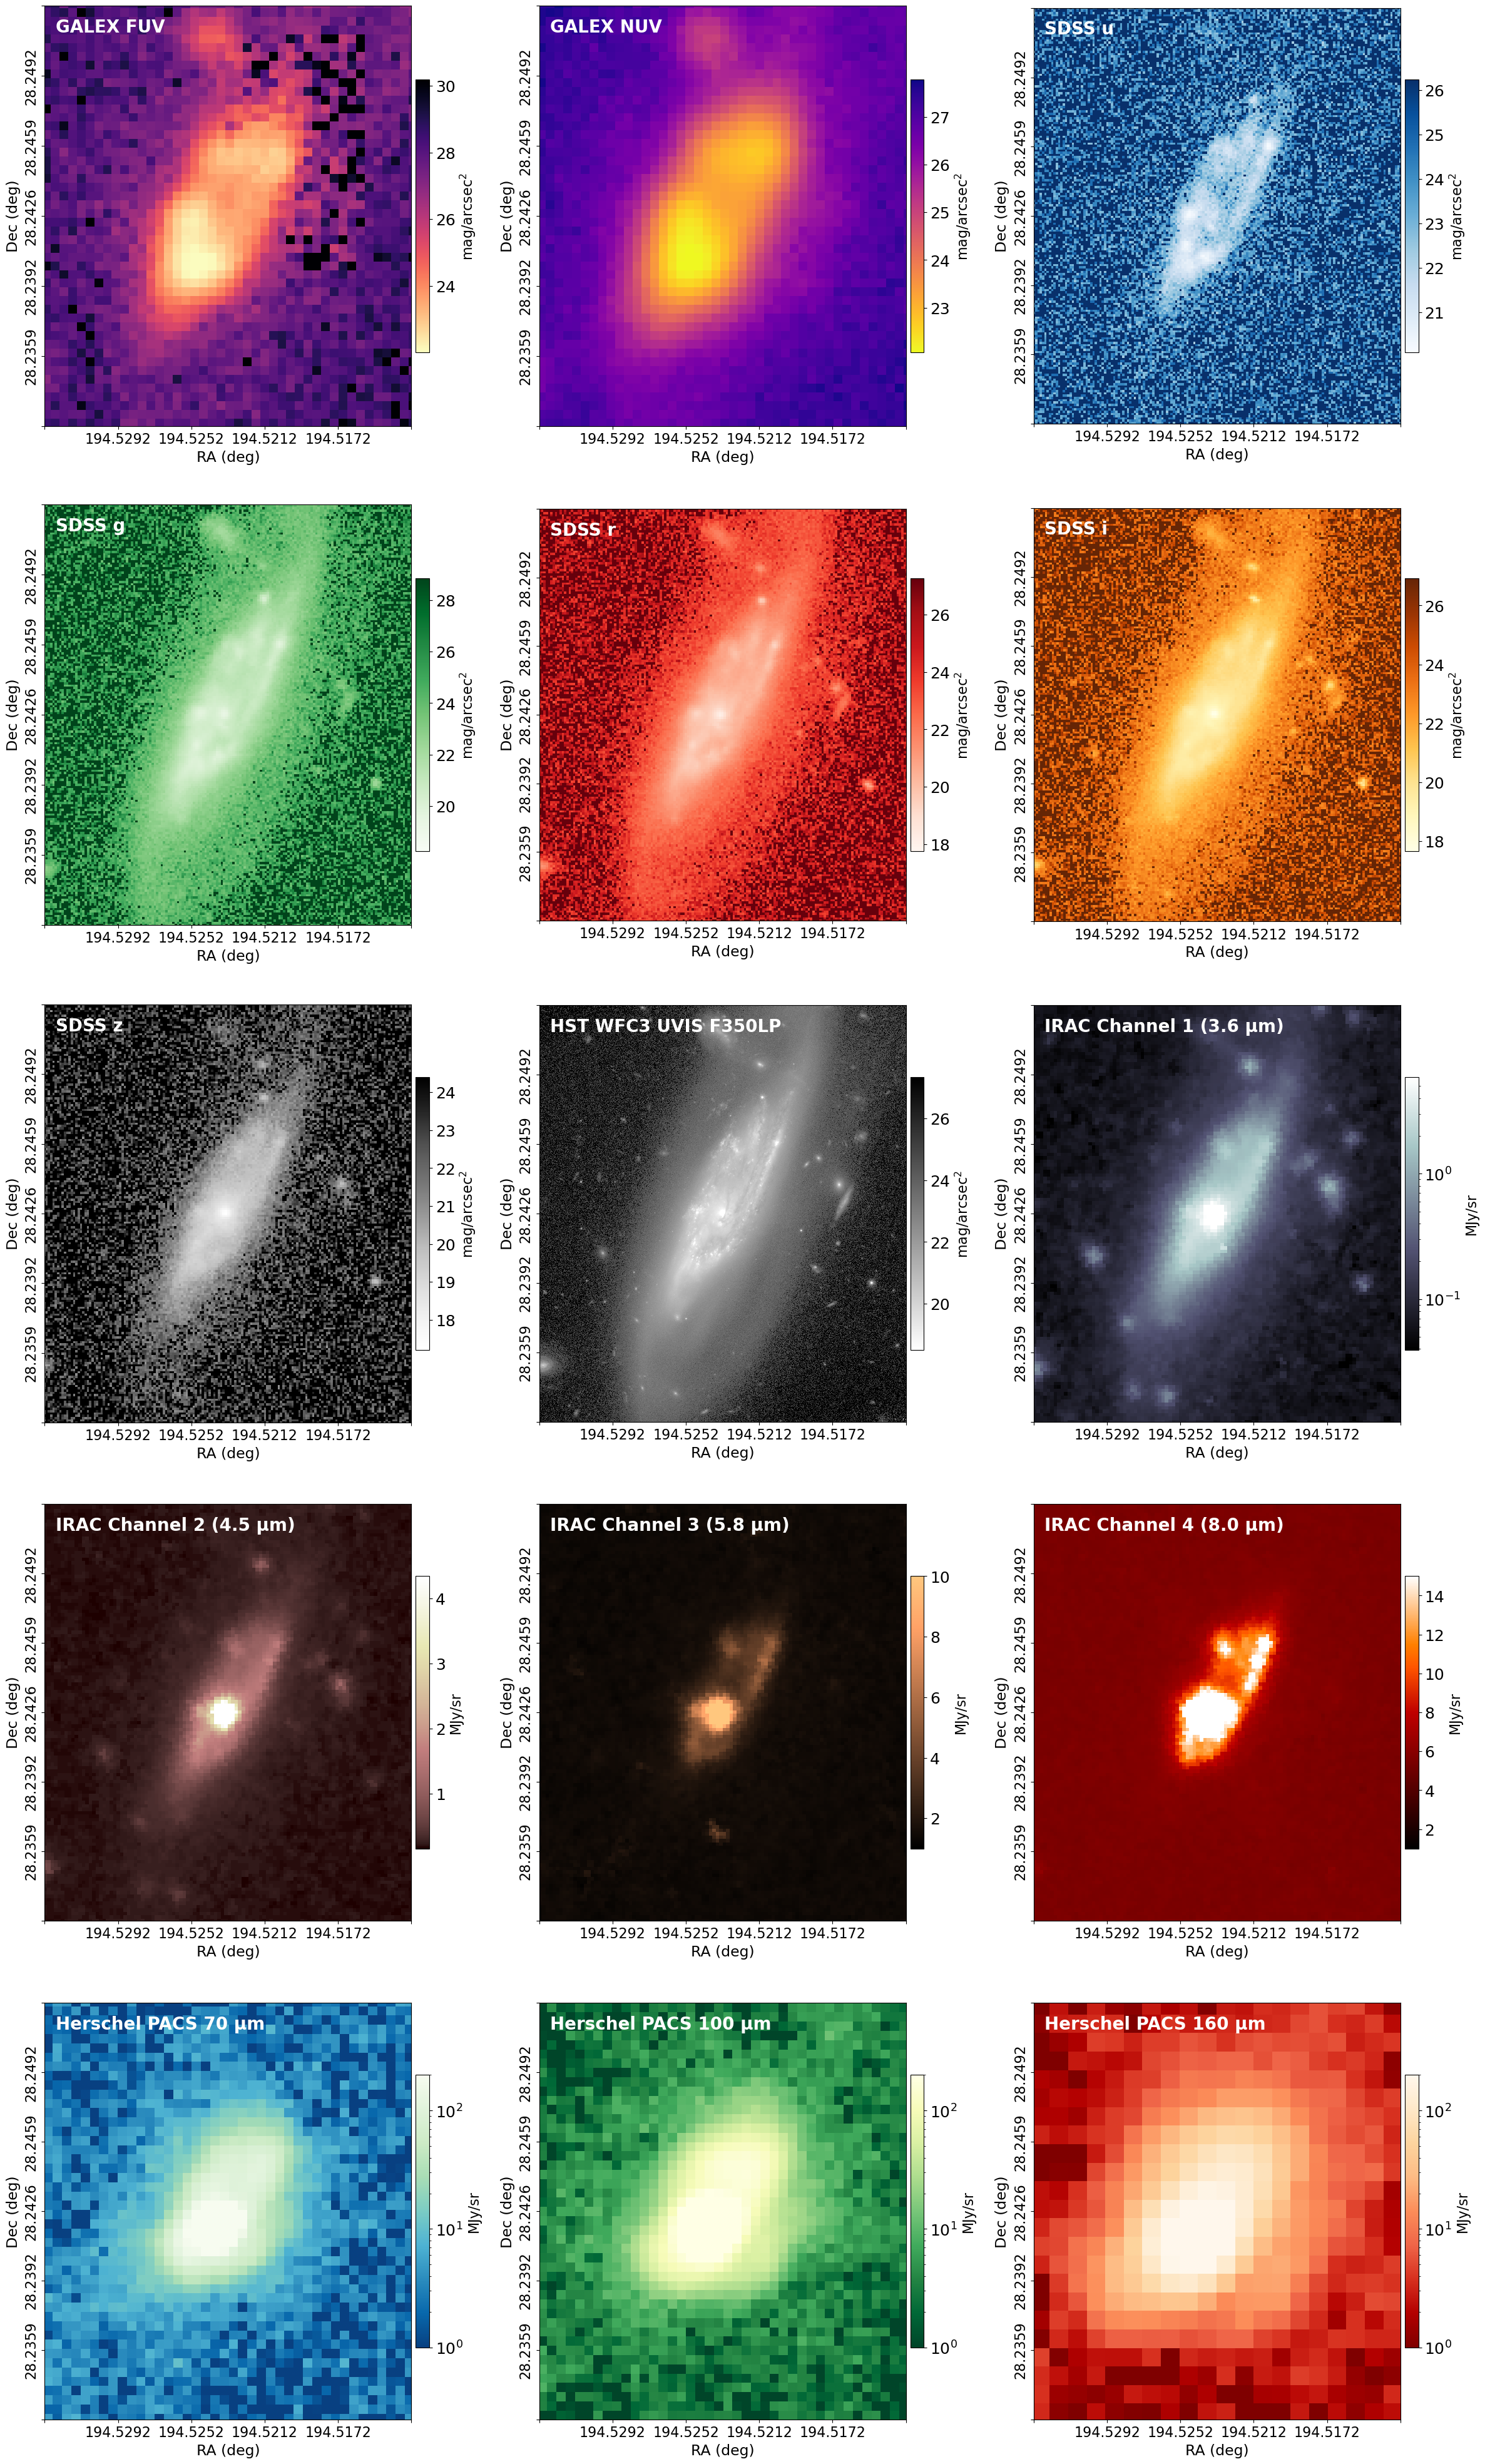

In [8]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z','hst_wfc3_uvis_f350lp','spitzer_irac_1',
                     'spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
                     'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
              
              plots_per_row=3, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,      
              axis_ticks_fontsize=16,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.01,
              ra_max = ra_center+0.01,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_cmaps = {'galex_nuv':'plasma',
                           'galex_fuv':'magma',
                           'spitzer_irac_1':'bone',
                           'spitzer_irac_2':'pink',
                           'spitzer_irac_3':'copper',
                           'spitzer_irac_4':'gist_heat',
                           'herschel_pacs_70um':'GnBu_r',
                           'herschel_pacs_100um':'YlGn_r',
                           'herschel_pacs_160um':'OrRd_r',
                          },
              
              set_scale_lims = {
                                'spitzer_irac_3':(1,10),
                                'spitzer_irac_4':(1,15),
                                'herschel_pacs_70um':(1,200),
                                'herschel_pacs_100um':(1,200),
                                'herschel_pacs_160um':(1,200),  
                               },         
            )



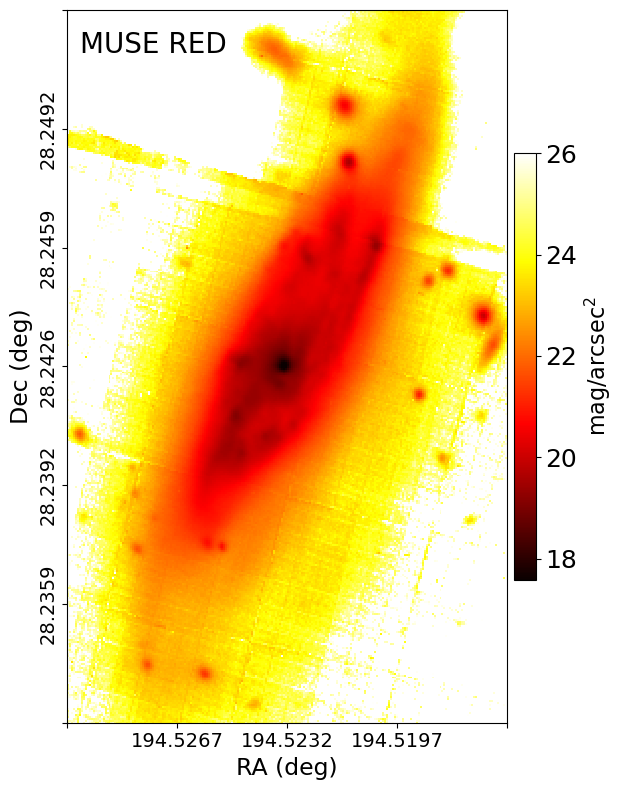

In [9]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              bands = ['muse_red'],
              plots_per_row=1, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=0,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='black',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=14,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=3,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_cmaps = {'muse_red':'hot_r'},

            )



In [10]:
galaxy.cubes.muse.line_map(line='Ha', width=10, continuum_offset_1=50, continuum_offset_2=50, z=z_true,pangal_object=galaxy);
galaxy.cubes.muse.line_map(line='Hb', width=10, continuum_offset_1=50, continuum_offset_2=50, z=z_true,pangal_object=galaxy);

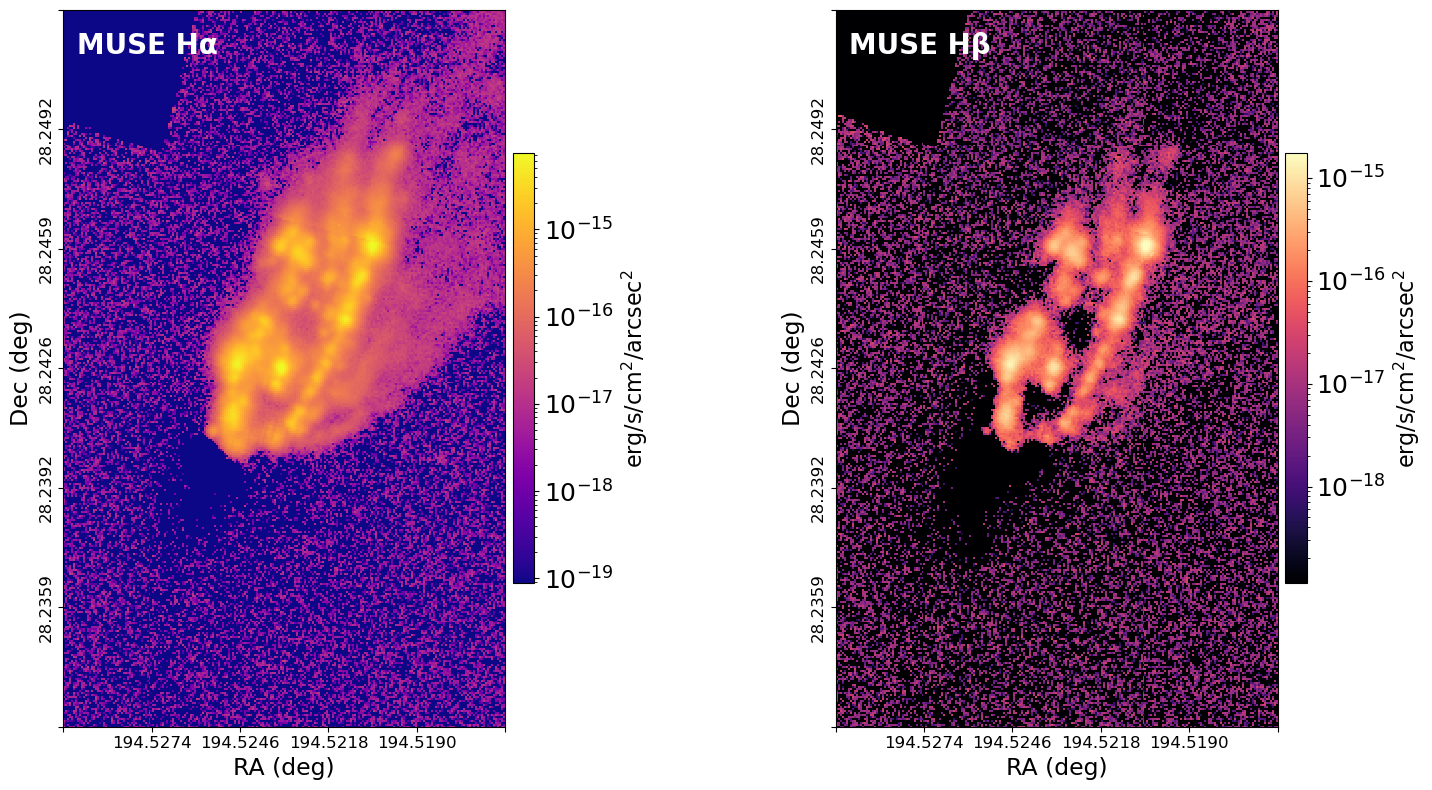

In [11]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['muse_Ha','muse_Hb'],
              
              plots_per_row=2, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=12,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_units = {'muse_Ha':'erg_s_cm2_arcsec2','muse_Hb':'erg_s_cm2_arcsec2'},
              set_cmaps = {'muse_Ha':'plasma','muse_Hb':'magma',},
      
            )

In [12]:
# Define regions to mask stars
circles = []
for ra, dec in [[ra_center,dec_center]]:
    circles.append(
        Region.circle(
            id = ' ',
            ra_center=ra, dec_center=dec, radius=0.001,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='purple'
        )
    )

# Define standard regions as ellipses
axis_ratio = 0.3
angle = 62

ellipses = []
for R in [10, 20, 3.23]:
    ellipses.append(
        Region.ellipse(
            id=f'NGC 4848: R {R} kpc',
            ra_center=ra_center, dec_center=dec_center,
            semimajor_axis=R * theta_deg_1kpc,
            axis_ratio=axis_ratio, angle=angle,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='gainsboro'
        )
    )

In [13]:
muse_obj = galaxy.images['muse_red']
npix_1kpc = theta_deg_1kpc / muse_obj.dtheta_pix_deg         # number of pixels corresponding to 1 kpc

image = muse_obj.erg_s_cm2_A

m_semimajor_ax = np.tan(angle*np.pi/180)
m_sep_line = -1/m_semimajor_ax

# REGIONS FOR MC-SPF
# Define the separator (regions must exclude Ha and Hb)

ra_x_p, dec_x_p = 194.5239703, 28.2387352
x_center, y_center = muse_obj.wcs.all_world2pix([[ra_center,dec_center]],1)[0] 

x_p, y_p = 114, 131
ra_x_p, dec_y_p = muse_obj.wcs.all_pix2world([[x_p, y_p]], 0)[0]

y_coords, x_coords = np.meshgrid(np.linspace(0, image.shape[0], image.shape[0]),np.linspace(0, image.shape[1], image.shape[1]),indexing='ij')
exclude_Ha_mask = (y_coords < m_sep_line * (x_coords - x_p) + y_p)
# REGIONS ARE DEFINED ON MUSE


regions_for_mcspf = []
from regions import EllipseAnnulusPixelRegion, PixCoord
from astropy import units as u

for i,r_kpc in enumerate(np.arange(6,18,3)):

    dr = 3
    region = EllipseAnnulusPixelRegion(
        center=PixCoord(x_center, y_center),
        inner_width = 2 * r_kpc * npix_1kpc, 
        outer_width = 2 * (r_kpc+dr) * npix_1kpc,  
        inner_height = axis_ratio * 2 * r_kpc * npix_1kpc,  
        outer_height = axis_ratio * 2 * (r_kpc+dr) * npix_1kpc,
        angle = angle*u.deg  
    )

    mask_elliptical_annulus = region.to_mask(mode='center').to_image(image.shape).astype(bool)
    mask = np.zeros_like(image, dtype=bool)
    mask |= (mask_elliptical_annulus & exclude_Ha_mask.astype(bool))


    if np.any(mask):

        R = r_kpc + dr/2
        print(R)
        x_centroid = x_center - R * npix_1kpc * np.cos(angle*np.pi/180)
        y_centroid = m_semimajor_ax * (x_centroid - x_center) + y_center 
        ra,dec = muse_obj.wcs.all_pix2world([[x_centroid, y_centroid]], 0)[0]

        regions_for_mcspf.append(Region(id=str(i+1),mask=mask,wcs=muse_obj.wcs,caption_coords = [ra,dec],)) 

for reg in regions_for_mcspf:
    reg.to_ds9('DATA/Coma/NGC4848/regions',append=True)
    

7.5
10.5
13.5
16.5
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg


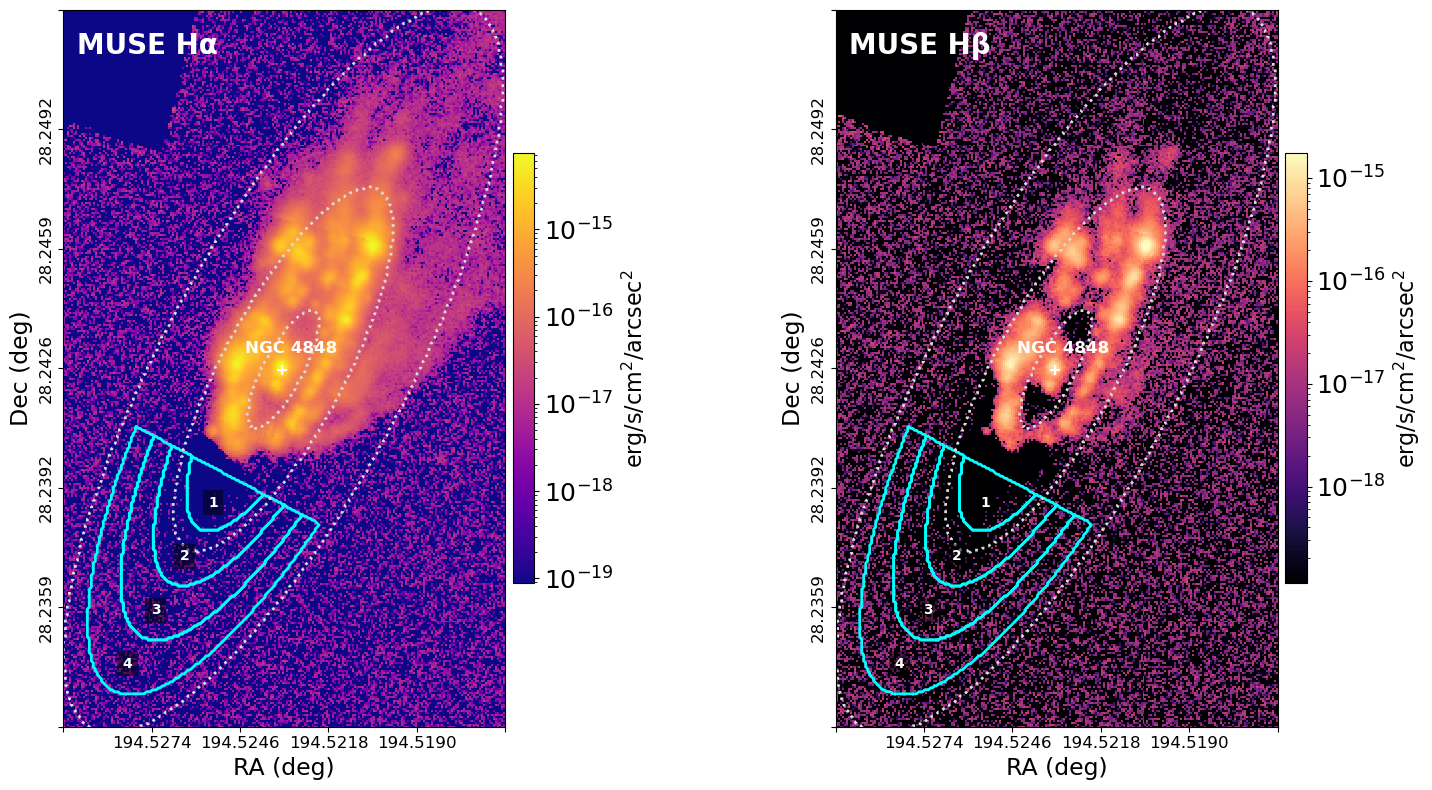

In [18]:
p = Point(coords=(ra_center,dec_center),caption='NGC 4848',caption_fontsize=12,caption_offset=[0.02,0.03],color='white',)

galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['muse_Ha','muse_Hb'],
              
              plots_per_row=2, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=12,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_units = {'muse_Ha':'erg_s_cm2_arcsec2','muse_Hb':'erg_s_cm2_arcsec2'},
              set_cmaps = {'muse_Ha':'plasma','muse_Hb':'magma',},

              regions = regions_for_mcspf+ellipses,
              legend=True,
              legend_loc='lower right',
              points = [p],
      
            )

In [20]:
bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g',
         'sdss_r', 'sdss_i', 'sdss_z','hst_wfc3_uvis_f350lp','hst_wfc3_uvis_f600lp','spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um']

#'wise_w1','wise_w2','wise_w3','wise_w4'

phot_list = galaxy.photometry(regions_for_mcspf,background_exclude_regions=[ellipses[-1]],bands = bands,print_output=True)



GALEX NUV
Region 1: total flux: 1.00625, poisson unc: 0.00378, sky flux: 0.02956, sky std: 0.003886570050383081
	Flux = 0.03294 ± 0.00155 mJy, SNR = 21.22
Region 2: total flux: 0.80422, poisson unc: 0.00327, sky flux: 0.07056, sky std: 0.008827383967440284
	Flux = 0.02475 ± 0.00118 mJy, SNR = 20.92
Region 3: total flux: 0.51419, poisson unc: 0.00245, sky flux: 0.10426, sky std: 0.01235312036799521
	Flux = 0.01383 ± 0.00077 mJy, SNR = 18.06
Region 4: total flux: 0.42236, poisson unc: 0.00203, sky flux: 0.14008, sky std: 0.01552840698682699
	Flux = 0.00952 ± 0.00069 mJy, SNR = 13.87


GALEX FUV
Region 1: total flux: 0.18549, poisson unc: 0.00247, sky flux: 0.00294, sky std: 0.0010637369371128231
	Flux = 0.01965 ± 0.00095 mJy, SNR = 20.68
Region 2: total flux: 0.10954, poisson unc: 0.00185, sky flux: 0.00685, sky std: 0.0021543241640817816
	Flux = 0.01105 ± 0.00059 mJy, SNR = 18.61
Region 3: total flux: 0.05220, poisson unc: 0.00118, sky flux: 0.01056, sky std: 0.0034464073606685075
	Flux

In [22]:
phot_list.print()

,1,2,3,4
GALEX NUV,0.033 ± 0.002 (21.2),0.025 ± 0.001 (20.9),0.014 ± 0.001 (18.1),0.010 ± 0.001 (13.9)
GALEX FUV,0.020 ± 0.001 (20.7),0.011 ± 0.001 (18.6),0.004 ± 0.000 (10.1),0.003 ± 0.000 (6.3)
SDSS u,0.103 ± 0.006 (18.3),0.065 ± 0.010 (6.4),0.044 ± 0.019 (2.3),0.010 ± 0.029 (0.3)
SDSS g,0.351 ± 0.005 (73.6),0.255 ± 0.007 (35.4),0.163 ± 0.009 (18.2),0.116 ± 0.012 (10.0)
SDSS r,0.530 ± 0.007 (73.6),0.431 ± 0.010 (43.0),0.284 ± 0.014 (20.0),0.195 ± 0.024 (8.1)
SDSS i,0.660 ± 0.009 (70.9),0.567 ± 0.020 (29.0),0.394 ± 0.028 (14.1),0.271 ± 0.034 (8.0)
SDSS z,0.793 ± 0.026 (30.4),0.684 ± 0.049 (13.9),0.518 ± 0.074 (7.0),0.366 ± 0.118 (3.1)
HST WFC3 UVIS F350LP,0.499 ± 0.007 (70.2),0.377 ± 0.010 (38.1),0.246 ± 0.014 (17.8),0.171 ± 0.019 (9.2)
HST WFC3 UVIS F600LP,0.722 ± 0.010 (70.2),0.579 ± 0.014 (42.8),0.380 ± 0.018 (21.7),0.258 ± 0.027 (9.6)
IRAC Channel 1 (3.6 μm),0.486 ± 0.007 (69.3),0.467 ± 0.011 (42.8),0.365 ± 0.015 (25.0),0.266 ± 0.019 (14.1)


In [24]:
phot_list.to_ABmag()#.print()

PhotometryTable(data={'1': {'galex_nuv': (20.10561164305678, 0.05116523549465648), 'galex_fuv': (20.666492372983733, 0.052492618323810955), 'sdss_u': (18.86360663923576, 0.05934606154794438), 'sdss_g': (17.53746605951327, 0.014760834273568758), 'sdss_r': (17.08982072644827, 0.014760834273568764), 'sdss_i': (16.851309123712984, 0.015323285489650075), 'sdss_z': (16.65155044597688, 0.03577181857225843), 'hst_wfc3_uvis_f350lp': (17.15431803654047, 0.015455815104064113), 'hst_wfc3_uvis_f600lp': (16.753426257512395, 0.015455815104064111), 'spitzer_irac_1': (17.183680165376018, 0.015658213437728934), 'spitzer_irac_2': (17.708806883762406, 0.02451673746037638), 'spitzer_irac_3': (17.776050171420895, 0.09152710335216685), 'spitzer_irac_4': (17.631050824340477, 0.07395379534454131), 'herschel_pacs_70um': (14.517088311445796, 0.12866753971972325), 'herschel_pacs_160um': (14.726028160953886, 0.054839352428785786), 'herschel_pacs_100um': (13.844712380679628, 0.07972657324859991)}, '2': {'galex_nuv'

In [26]:
#phot_list.to_ABmag().print()

In [27]:
phot_list.to_fits('DATA/Coma/NGC4848/photometry_ngc4848.dat')

Written 4 photometry table(s) to DATA/Coma/NGC4848/photometry_ngc4848.dat


In [28]:
from astropy.io import fits
with fits.open('DATA/Coma/NGC4848/photometry_ngc4848.dat') as hdul:
    hdul.info()

Filename: DATA/Coma/NGC4848/photometry_ngc4848.dat
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOT_1        1 BinTableHDU     20   16R x 4C   [20A, D, D, D]   
  2  PHOT_2        1 BinTableHDU     20   16R x 4C   [20A, D, D, D]   
  3  PHOT_3        1 BinTableHDU     20   16R x 4C   [20A, D, D, D]   
  4  PHOT_4        1 BinTableHDU     20   16R x 4C   [20A, D, D, D]   


In [67]:
spectra = galaxy.cubes.muse.extract_spectra(regions=regions_for_mcspf,pangal_object=galaxy)

In [68]:
spectra[0].header

HIERARCH SOURCE_ID = 'CUBE    '                                                 
HIERARCH REGION_ID = '1       '                                                 
NPIXELS =                  861                                                  
FUNITS  = 'erg/s/cm2/A'                                                         
WUNITS  = 'A       '                                                            

In [69]:
for i,spec in enumerate(spectra):
    spec.header['REDSHIFT'] = z_true
    spec.to_fits(f'DATA/Coma/NGC4848/spectra_extracted_from_MUSE/muse_spectrum_region_{i+1:.0f}.spec')
    

In [70]:
spectra[0].header

HIERARCH SOURCE_ID = 'CUBE    '                                                 
HIERARCH REGION_ID = '1       '                                                 
NPIXELS =                  861                                                  
FUNITS  = 'erg/s/cm2/A'                                                         
WUNITS  = 'A       '                                                            
REDSHIFT=             0.023974                                                  

In [71]:
phot_list.header

{'XTENSION': 'BINTABLE',
 'BITPIX': 8,
 'NAXIS': 2,
 'NAXIS1': 44,
 'NAXIS2': 16,
 'PCOUNT': 0,
 'GCOUNT': 1,
 'TFIELDS': 4,
 'TTYPE1': 'BAND',
 'TFORM1': '20A',
 'TTYPE2': 'VALUE',
 'TFORM2': 'D',
 'TTYPE3': 'ERROR',
 'TFORM3': 'D',
 'TTYPE4': 'SNR',
 'TFORM4': 'D',
 'UNITS': 'mJy',
 'N_REGS': 4,
 'REGIONS': '1,2,3,4',
 'EXTNAME': 'PHOT_1'}

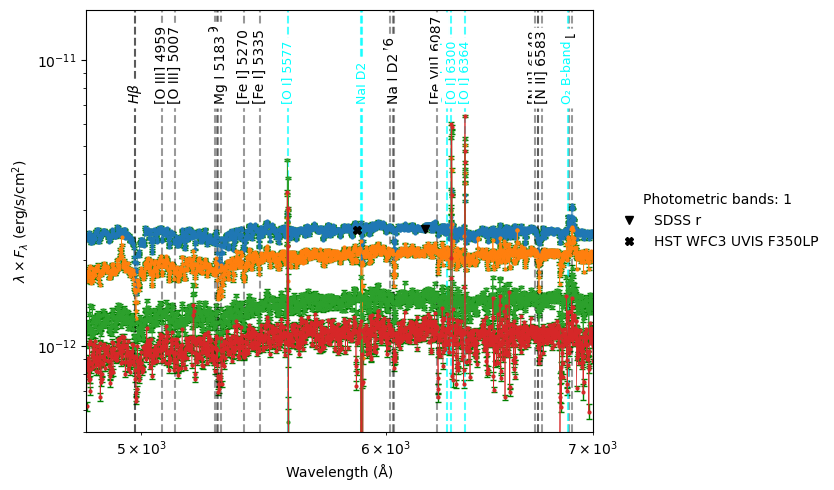

In [38]:
# IMPORTANT!!! FIX REDSHIFT!!!

spectra[0].plot(figsize=(10,5),spectra=spectra, per_wavelength=True, phot_points=phot_list, phot_region='1', #show_phot_legend=True,
              winf=4800,wsup=7000, 
                ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True) #,zoom_on_line=['Ha','Hb']
 

# Fitting the model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

#from pangal.pfitter import PFitter
from pangal.photometry_table import PhotometryTable

import warnings
warnings.simplefilter("ignore")

In [2]:
phot_list = PhotometryTable().from_fits('DATA/Coma/NGC4848/photometry_ngc4848.dat')
phot_list.print()

,1,2,3,4
GALEX NUV,0.033 ± 0.002 (21.2),0.025 ± 0.001 (20.9),0.014 ± 0.001 (18.1),0.010 ± 0.001 (13.9)
GALEX FUV,0.020 ± 0.001 (20.7),0.011 ± 0.001 (18.6),0.004 ± 0.000 (10.1),0.003 ± 0.000 (6.3)
SDSS u,0.103 ± 0.006 (18.3),0.065 ± 0.010 (6.4),0.044 ± 0.019 (2.3),0.010 ± 0.029 (0.3)
SDSS g,0.351 ± 0.005 (73.6),0.255 ± 0.007 (35.4),0.163 ± 0.009 (18.2),0.116 ± 0.012 (10.0)
SDSS r,0.530 ± 0.007 (73.6),0.431 ± 0.010 (43.0),0.284 ± 0.014 (20.0),0.195 ± 0.024 (8.1)
SDSS i,0.660 ± 0.009 (70.9),0.567 ± 0.020 (29.0),0.394 ± 0.028 (14.1),0.271 ± 0.034 (8.0)
SDSS z,0.793 ± 0.026 (30.4),0.684 ± 0.049 (13.9),0.518 ± 0.074 (7.0),0.366 ± 0.118 (3.1)
HST WFC3 UVIS F350LP,0.499 ± 0.007 (70.2),0.377 ± 0.010 (38.1),0.246 ± 0.014 (17.8),0.171 ± 0.019 (9.2)
HST WFC3 UVIS F600LP,0.722 ± 0.010 (70.2),0.579 ± 0.014 (42.8),0.380 ± 0.018 (21.7),0.258 ± 0.027 (9.6)
IRAC Channel 1 (3.6 μm),0.486 ± 0.007 (69.3),0.467 ± 0.011 (42.8),0.365 ± 0.015 (25.0),0.266 ± 0.019 (14.1)


In [3]:
from pangal.spectrum import Spectrum
spectra = []
for i in range(4):
    spectra.append(Spectrum().from_fits(f'DATA/Coma/NGC4848/spectra_extracted_from_MUSE/muse_spectrum_region_{i+1:.0f}.spec'))

In [4]:
spec_0 = Spectrum().from_fits(f'DATA/Coma/NGC4848/spectra_extracted_from_MUSE/muse_spectrum_region_1.spec')

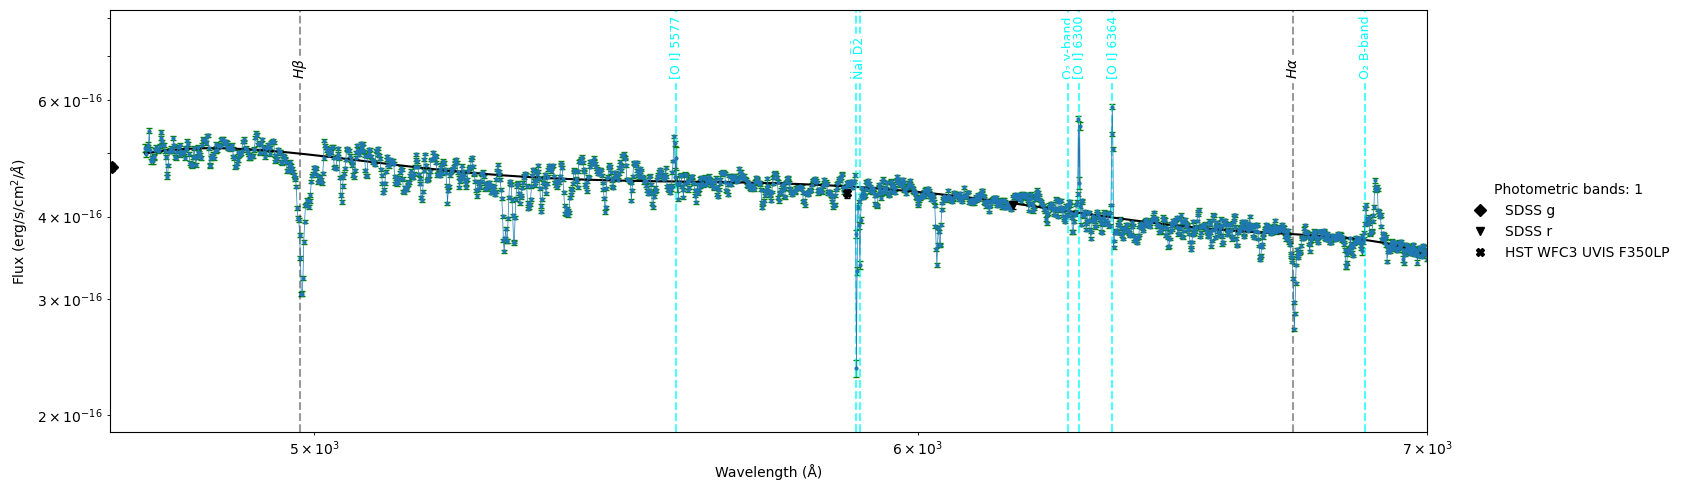

In [5]:

spectra[0].plot(figsize=(20,5), 
            spectra = [spectra[0],], #spectra[-1]
            #remove_continuum=True,
            draw_continuum=True,
            #normalized=True,
            per_wavelength=False, 
            phot_points=phot_list, phot_region='1', show_spec_legend=False,
            
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=4700,wsup=7000,
            #ymin = 0.5,ymax=1.5,
           )
 

In [6]:
#from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits
from pangal.pfitter import PFitter
from build_boissier import load_spectrum_models_from_fits

In [7]:
model_specs = load_spectrum_models_from_fits(filename='V_160_R_7_TEST.fit')

In [8]:

fitter = PFitter(model_specs,
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )



Initializing PFitter object
   Model parameters: Q_AGE, TAU_Q, BURST, METAL

 Pre-computed model grid:
   - Q_AGE: 24 values, min=0, max=1000
   - TAU_Q: 15 values, min=2, max=1000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 

In [9]:

custom_prior = {
    #'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    #'alpha':  {'type':'uniform', 'low':1.5,    'high':3},
    #'m_star':  {'type':'uniform', 'low':9.1,    'high':9.5},
    'sigma_vel': {'type':'uniform', 'low':0,    'high':400},
    'vel_sys': {'type':'uniform', 'low':-500,    'high':+500},
}

bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g','sdss_r', 'sdss_i', 'sdss_z',
         'hst_wfc3_uvis_f350lp','hst_wfc3_uvis_f600lp',
         'spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 
         'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um']
        
#'wise_w1','wise_w2','wise_w3','wise_w4'



In [ ]:
results_only_phot = fitter.run_fit(
                         obj_id = '1',
                         phot=phot_list, 
                         fix_pars={'ion_gas':-3.94,'age_gas':13,'redshift':0.023974, #'av_ext':0, 'fesc':1.
                                   'luminosity_distance':100,'BURST':0.0,'METAL':0.017},
                         nlive=100,
                         dlogz=0.1,
                         spectral_range=[4800,7000],
                         custom_priors=custom_prior,
                         )


Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_160um, herschel_pacs_100um

Priors:
  - Q_AGE: Uniform(0, 1000)
  - TAU_Q: Uniform(2, 1000)
  - fesc: Uniform(0.0, 1.0)
  - av: Uniform(0.0, 1.0)
  - av_ext: Uniform(0.0, 1.0)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(7.0, 11.0)
Initializing live points


2470it [03:11, 15.01it/s, bound: 269 | nc: 16 | ncall: 43928 | eff(%):  5.623 | loglstar:   -inf < -9.244 <    inf | logz: -31.993 +/-  0.451 | dlogz:  0.794 >  0.100]      

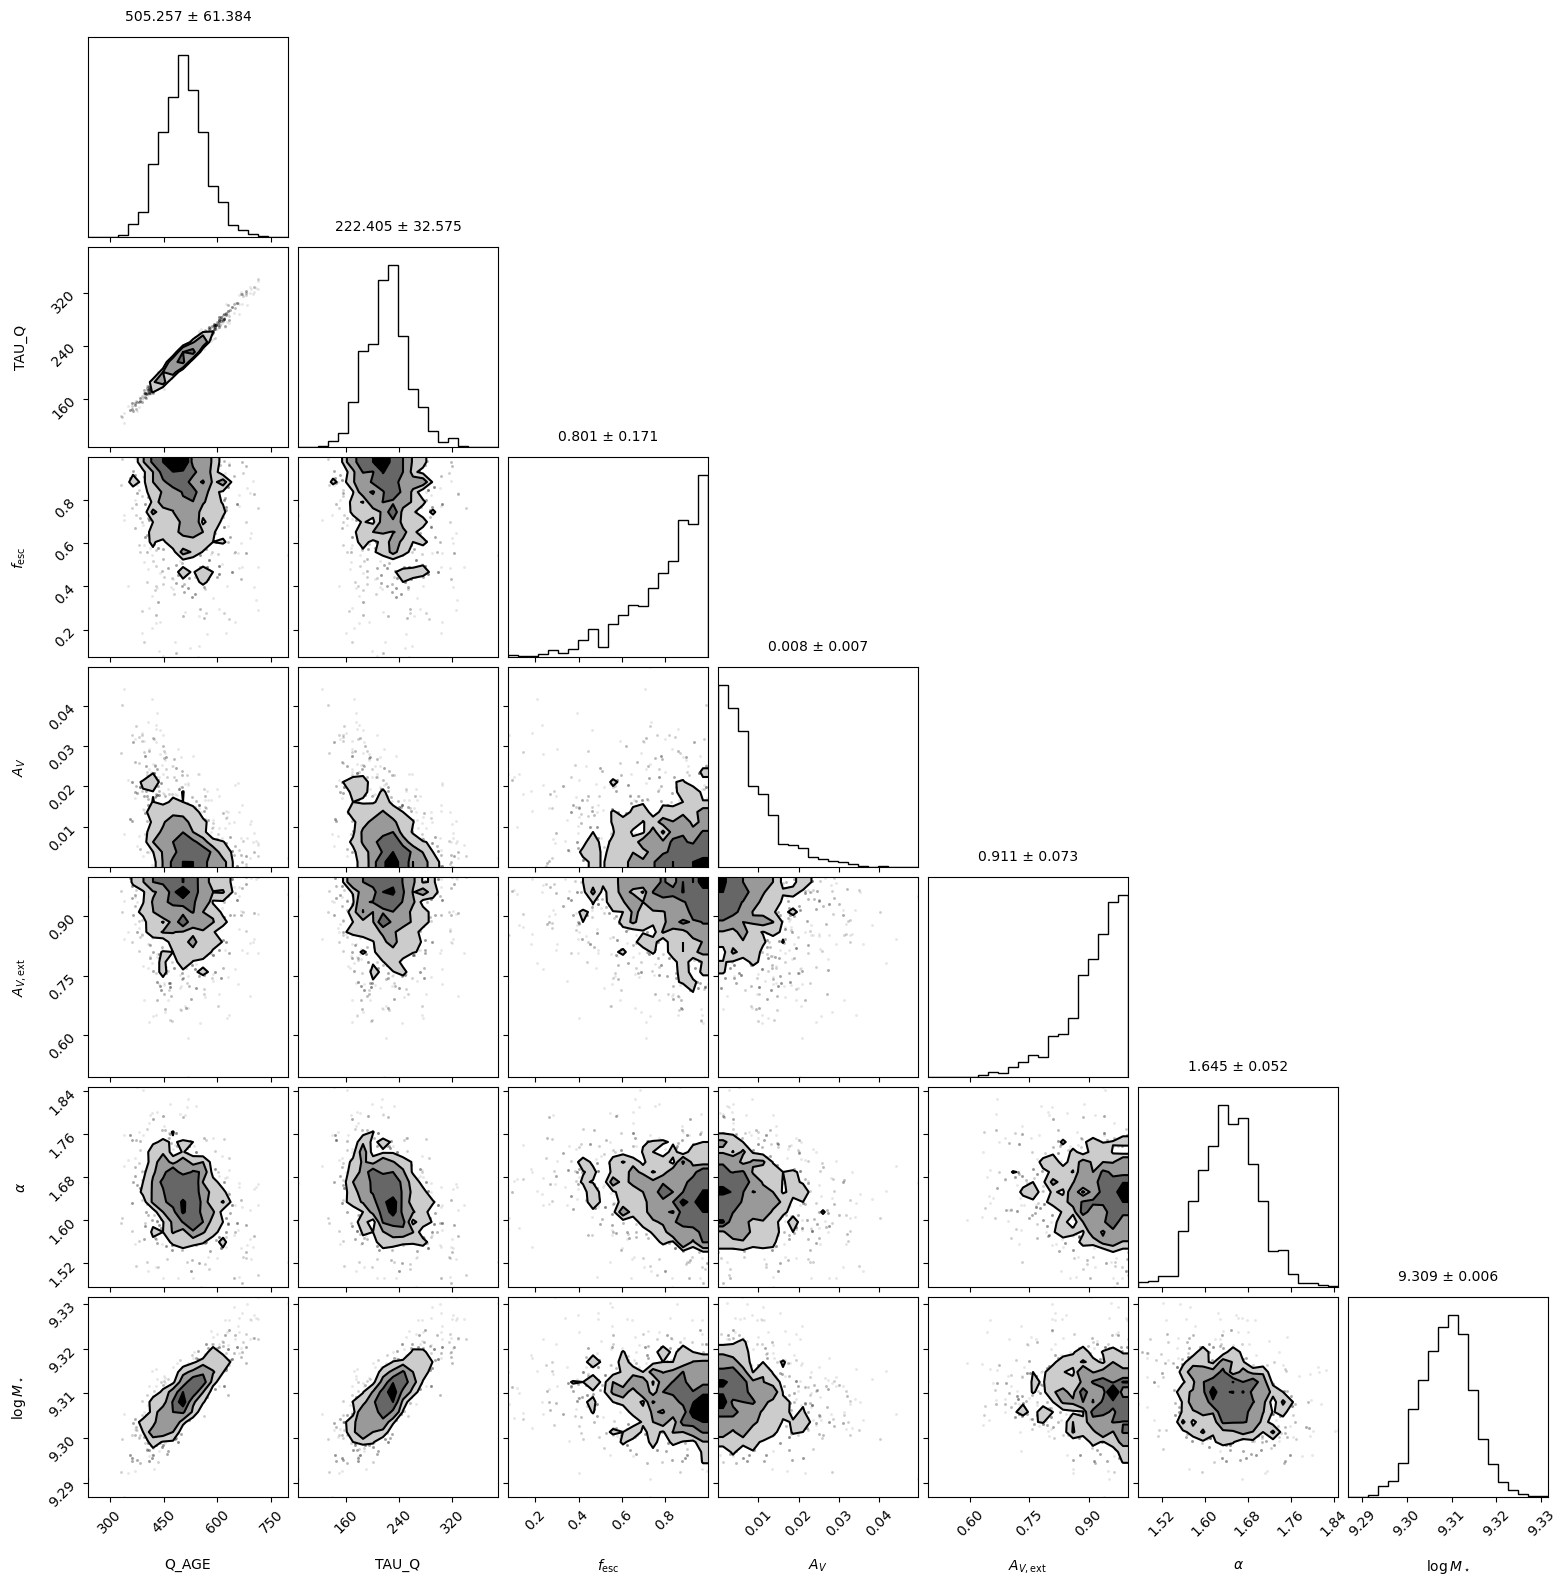

In [14]:
# NO BURST, METALLICITY = 0.017
results_only_phot.cornerplot()

In [10]:
results_with_spec = fitter.run_fit(
                         obj_id = '1',
                         phot=phot_list, 
                         #bands=bands, 
                         spec=spectra[0],
                         fix_pars={'ion_gas':-3.94,'age_gas':13,#'fesc':1.,
                                   #'av':0.0957,'alpha':1.7836,'av_ext':0,
                                   'redshift':0.023974,'luminosity_distance':100,
                                   'BURST':0.0,'METAL':0.017},
                         nlive=100,
                         dlogz=0.1,
                         spectral_range=[4800,7000],
                         custom_priors=custom_prior,
                         polymax=7,
                         )


Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_160um, herschel_pacs_100um

Priors:
  - Q_AGE: Uniform(0, 1000)
  - TAU_Q: Uniform(2, 1000)
  - fesc: Uniform(0.0, 1.0)
  - av: Uniform(0.0, 1.0)
  - av_ext: Uniform(0.0, 1.0)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(7.0, 11.0)
  - vel_sys: Uniform(-500, 500)
  - sigma_vel: Uniform(0, 400)
Initializing live points


4073it [26:51,  2.53it/s, +100 | bound: 1067 | nc: 1 | ncall: 164020 | eff(%):  2.546 | loglstar:   -inf < 54389.633 <    inf | logz: 54351.408 +/-  0.589 | dlogz:  0.001 >  0.100]


In [11]:
results_with_spec.save('run_with_spec')

Saved fit results to run_with_spec


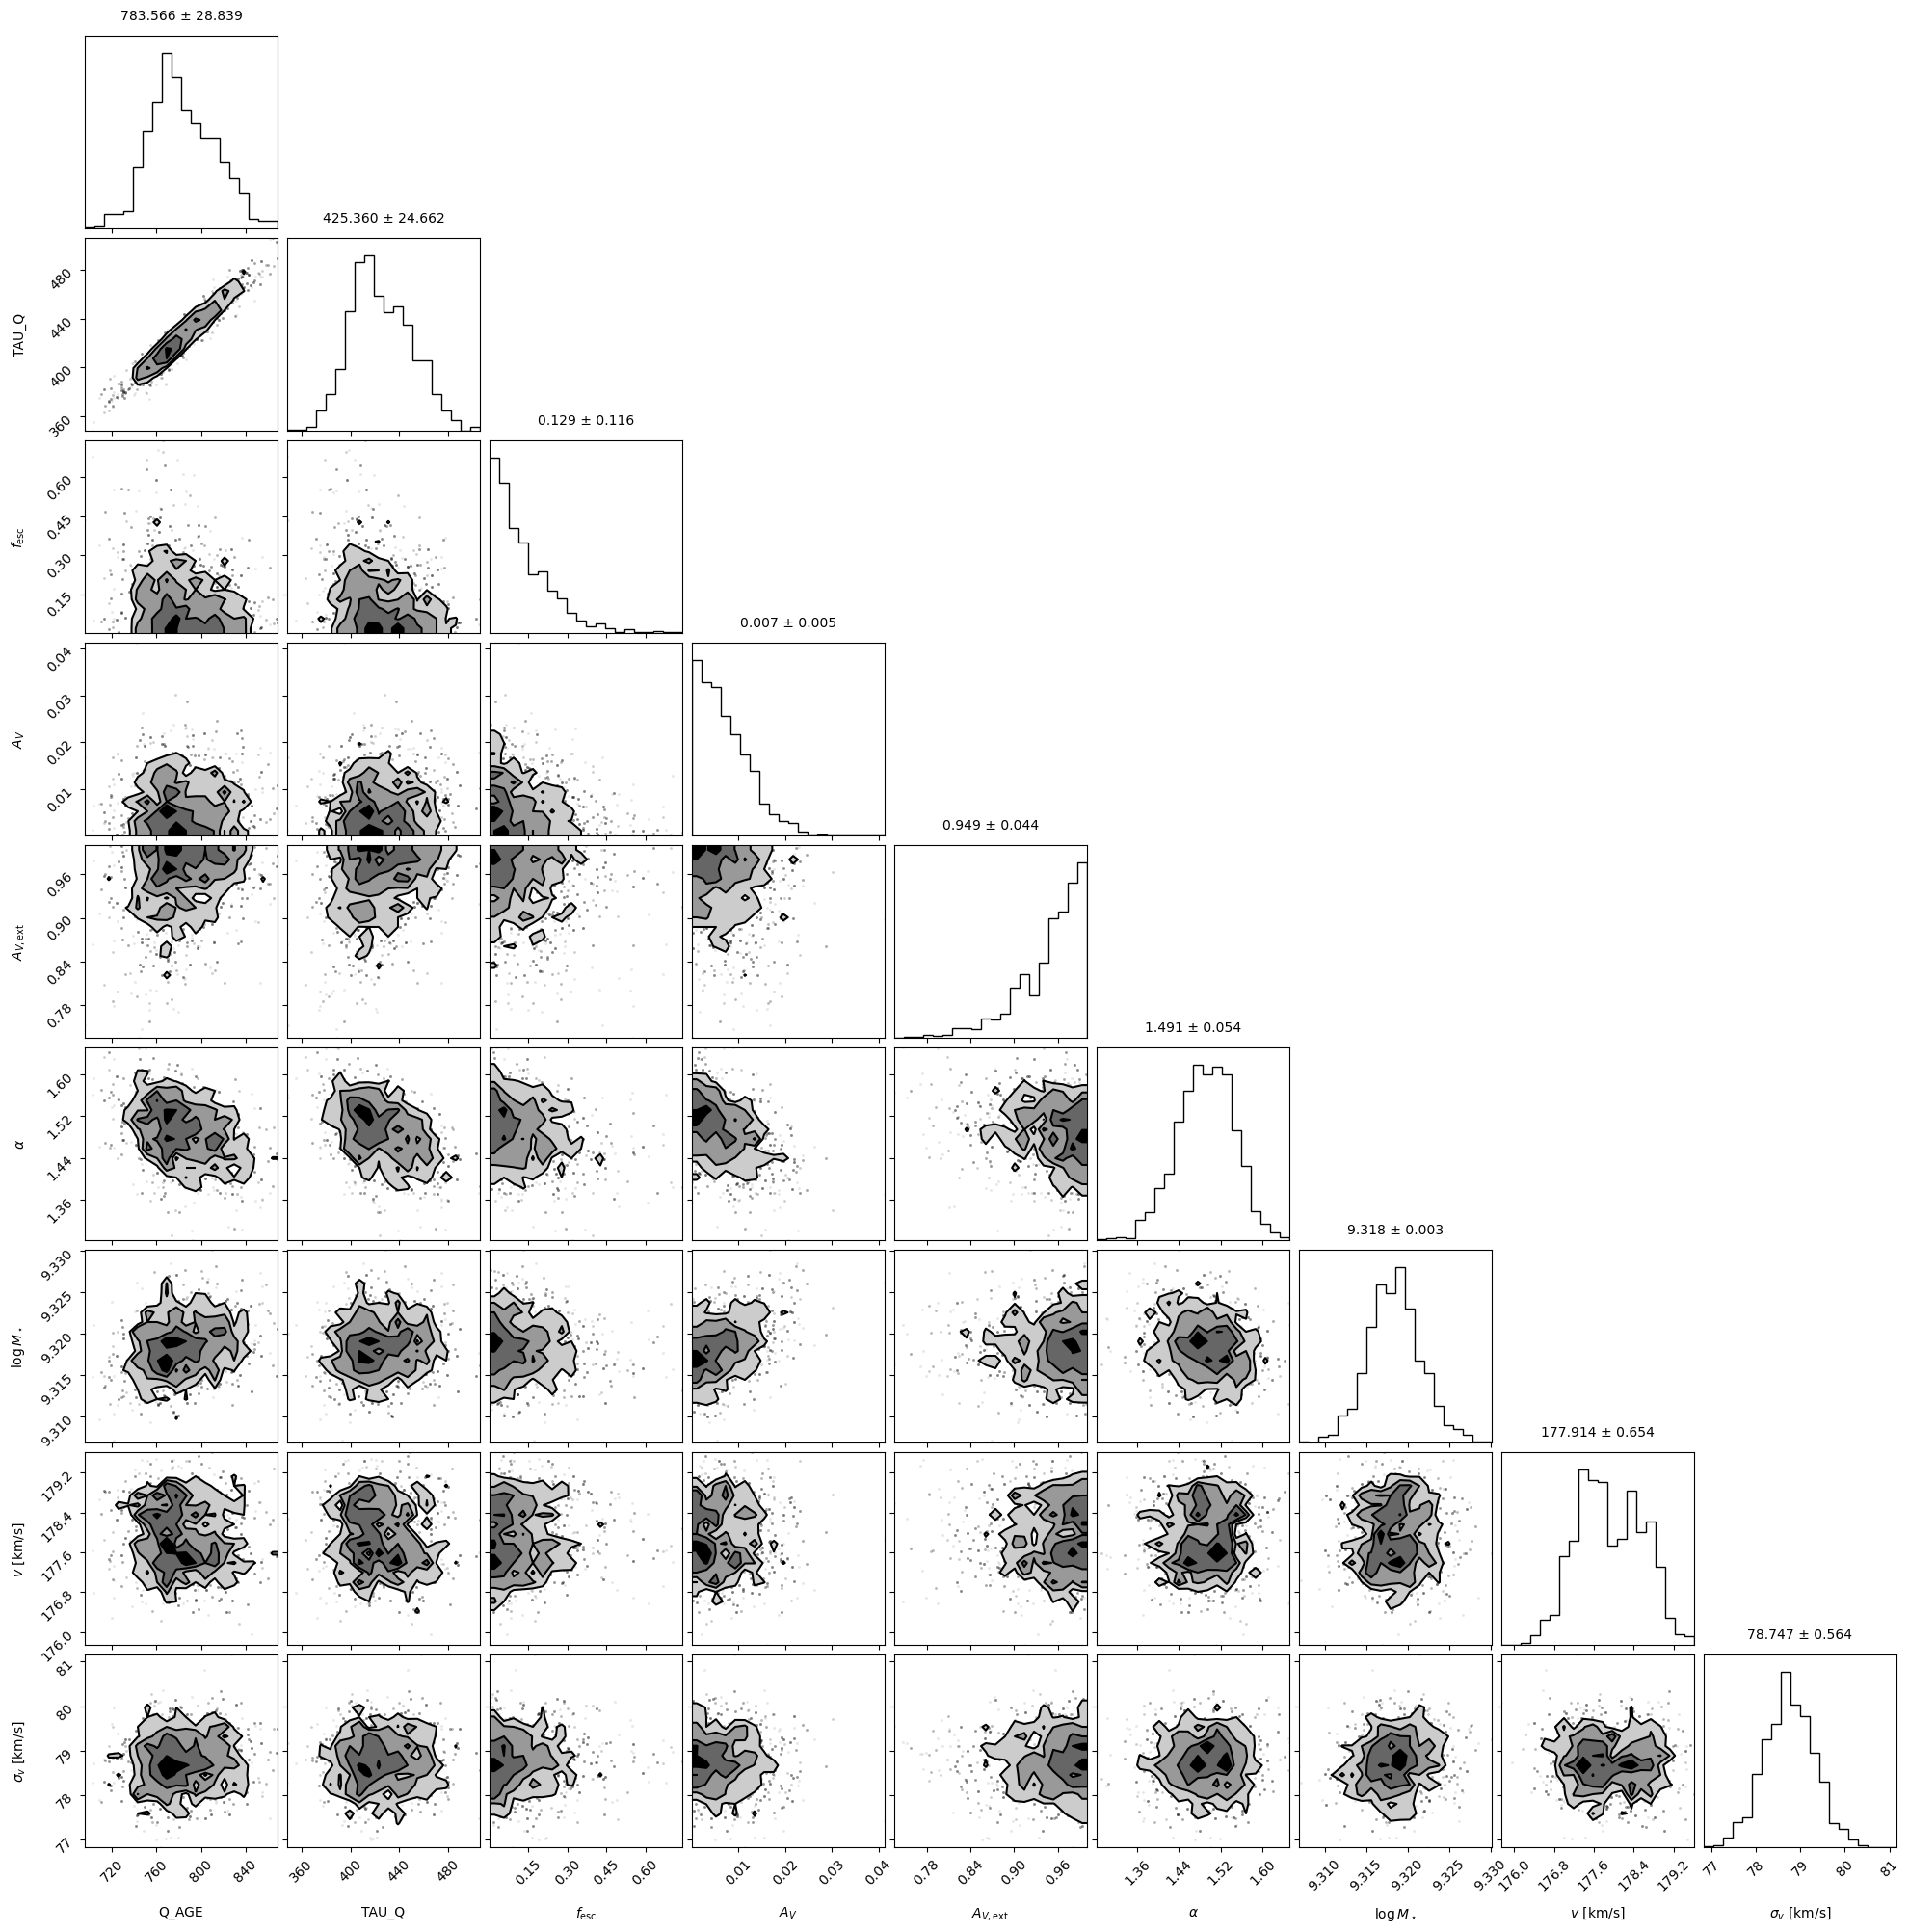

In [12]:
results_with_spec.cornerplot()

In [218]:

hdr = results_only_phot.best_model().header
vel_sys   = results_with_spec.best_model().header["vel_sys"]
sigma_vel = results_with_spec.best_model().header["sigma_v"]
av        = hdr["av"]
av_ext    = hdr["av_ext"]
alpha     = hdr["alpha"]
fesc      = hdr["fesc"]
ion_gas   = hdr["ion_gas"]
age_gas   = hdr["age_gas"]
Q_AGE     = hdr["Q_AGE"]
TAU_Q     = hdr["TAU_Q"]
BURST     = hdr["BURST"]
METAL     = hdr["METAL"]
m_star    = hdr["mstar"]
redshift  = hdr["redshift"]
luminosity_distance = hdr["dl_mpc"]

best_model_phot = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=Q_AGE,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)

third_spec = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=1000,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)


results_with_spec.best_model().plot(figsize=(20,5), 
            #remove_continuum=True,
             spectra=[best_model_phot,results_with_spec.best_model(),third_spec], #spectra[0]
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Hd','Hb','Ha',],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=1000,wsup=2e6,
            #winf = 6200,wsup=7200,
            #winf = 6600,wsup=6750,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars='Q_AGE',
            show_phot_legend=False,
            show_spec_legend=True,
            ecolor='gray',
            color=['black','orange','blue','green'],
           )



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 hdr = results_only_phot.best_model().header                                                 │
│    2 vel_sys   = results_with_spec.best_model().header["vel_sys"]                                │
│    3 sigma_vel = results_with_spec.best_model().header["sigma_v"]                                │
│    4 av        = hdr["av"]                                                                       │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'results_only_phot' is not defined

In [37]:
#results_with_spec.continuum

In [178]:
results_with_spec.polymax

7

In [216]:
from astropy.io import fits
from scipy.interpolate import interp1d

def fit_diagnostic(run,
                    spectra=[],
                    # plotting window
                    winf=None,
                    wsup=None,

                    # aestethics
                    figsize=None,
                    color=None,
                    
                    # optionals
                    redshift=None,
                    show_H_lines=False,
                    show_all_spectral_lines=False,
                    show_atmospheric_lines=False,
                    show_filters=False,
                    
                    spec_legend_pars=None,
                    spec_legend_loc="upper left",
                    spec_legend_title=None,
                   ):

    self = run
    
    wl, flux_obs, flux_err, = self.spec_wl, self.spec_flux, self.spec_flux_err
    header = fits.Header()
    header["WUNITS"]  = "A"
    header["FUNITS"]  = "erg/s/cm2/A"
    spectrum_obs = Spectrum(wl=wl,flux=flux_obs,flux_err=flux_err,header=header)

    model_spectra = [self.best_model(method=method)] + spectra 

    
    normalization_factor_list = []
    normalization_factor_smoothed_list = []
    models_comparable_to_obs = []
    residuals = []
    
    for synth_spec in model_spectra:

        normalization_factor, normalization_factor_smoothed, model = self._adapt_model_spectrum_to_observed_spectrum(synth_spec)

        normalization_factor_list.append(normalization_factor)
        normalization_factor_smoothed_list.append(normalization_factor_smoothed)
    
        models_comparable_to_obs.append(model)

        res = (flux_obs - model) / flux_err
        residuals.append(res)


    fig, ax = plt.subplots(2,2,figsize=(10,10))
    ax = ax.flatten()
    
    global_fmax = -np.inf
    global_fmin = +np.inf
    mask = (wl>winf) & (wl<wsup)

    global_norm_max = -np.inf
    global_norm_min = +np.inf
    global_res_max = -np.inf
    global_res_min = +np.inf

    for i in [0,2]:
        ax[i].errorbar(wl, flux_obs, yerr=flux_err, fmt='o', markersize=2,
                        color='black', ecolor='gray', elinewidth=1.0,
                        capsize=2, capthick=1.0, linestyle='-', lw=0.5,)
                        #label=label)

        global_fmax = max(np.nanmax(flux_obs[mask]),global_fmax)
        global_fmin = min(np.nanmin(flux_obs[mask]),global_fmin)
        
    for j,model in enumerate(model_spectra):

        # --- Color ---
        if isinstance(color, (list, tuple)) and len(color) > 0:
            c = color[j % len(color)]
        elif color is None:
            c = f"C{j % 10}" 
        else:
            c = color
    
        # --- Label ---
        if isinstance(spec_legend_pars, str):
            label = model.header[spec_legend_pars]
    
        elif isinstance(spec_legend_pars, dict):
            label = ", ".join(
                f"{spec_legend_pars[k][0]}={model.header[k]:.2f} {spec_legend_pars[k][1]}"
                for k in spec_legend_pars
                if k in model.header
            )   
        else:
            label = model.header.get("ID", getattr(model, "id", None)) or f"Spectrum {i + 1}"

        
        ax[0].plot(model.wl,model.flux,color=c,label=label)

        mask_m = (model.wl > winf) & (model.wl < wsup)
        global_fmax = max(global_fmax, np.nanmax(model.flux[mask_m]))
        global_fmin = min(global_fmin, np.nanmin(model.flux[mask_m]))
        

        ax[1].plot(wl,normalization_factor_list[j],color=c,alpha=0.3)
        ax[1].plot(wl,normalization_factor_smoothed_list[j],color=c,label=f'deg = {self.polymax:.0f}')
        
        global_norm_max = max(np.nanmax(normalization_factor_list[j][mask]),global_norm_max)
        global_norm_min = min(np.nanmin(normalization_factor_list[j][mask]),global_norm_min)
        
        ax[2].plot(wl,models_comparable_to_obs[j],color=c)

        chi2 = np.nansum(residuals[j])
        ax[3].scatter(wl,residuals[j],s=1,alpha=0.5,color=c,label=f"$\chi_2=${chi2:.2f}")

        global_res_max = max(np.nanmax(residuals[j][mask]),global_res_max)
        global_res_min = min(np.nanmin(residuals[j][mask]),global_res_min)
        

    for i in range(4):
        ax[i].set_xlim(winf,wsup)

    for i in [0,2]:
        ax[i].set_ylim(0.8*global_fmin,1.2*global_fmax)

    ax[1].set_ylim(0.8*global_norm_min,1.2*global_norm_max)
    ax[3].set_ylim(0.8*global_res_min,1.2*global_res_max)

    ax[3].axhline(y=0,color='black',lw=1)

    ax[0].legend() #title=spec_legend_pars
    ax[2].legend() #title=spec_legend_pars
    ax[3].legend() #title=spec_legend_pars


In [213]:
print(np.mean(spectra[0].flux_err))

2.256666366447583e-18


In [217]:
fit_diagnostic(results_with_spec,per_wavelength=True, 
               spectra=[best_model_phot],
            #remove_continuum=True,
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Hb','Ha',],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4800,wsup=7000,
            spec_legend_pars={'Q_AGE':["$Q_\\text{age}$",'Myr'],'TAU_Q':["$\\tau_Q$",'Myr']},
            ecolor='gray',
            color=['black','red','blue'],
           )


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│    1 fit_diagnostic(results_with_spec,per_wavelength=True,                                       │
│ ❱  2 │   │   │      spectra=[best_model_phot],                                                   │
│    3 │   │   │   #remove_continuum=True,                                                         │
│    4 │   │   │   show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,     │
│    5 │   │   │   #zoom_on_line=['Hb','Ha',],                                                     │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'best_model_phot' is not defined

In [206]:
#results_with_spec.save('DATA/Coma/NGC4848/dynesty_Results/reg_1_spec.npz')

In [207]:
best_model_spec

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 best_model_spec                                                                              │
│   2                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'best_model_spec' is not defined

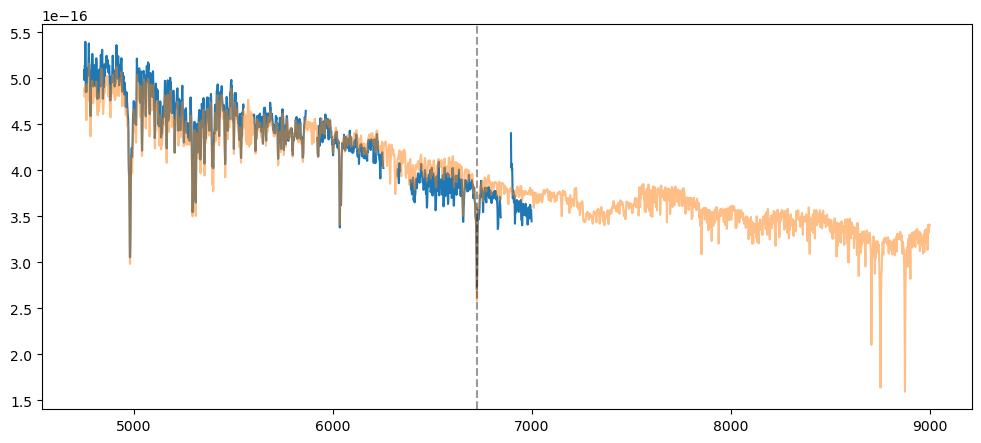

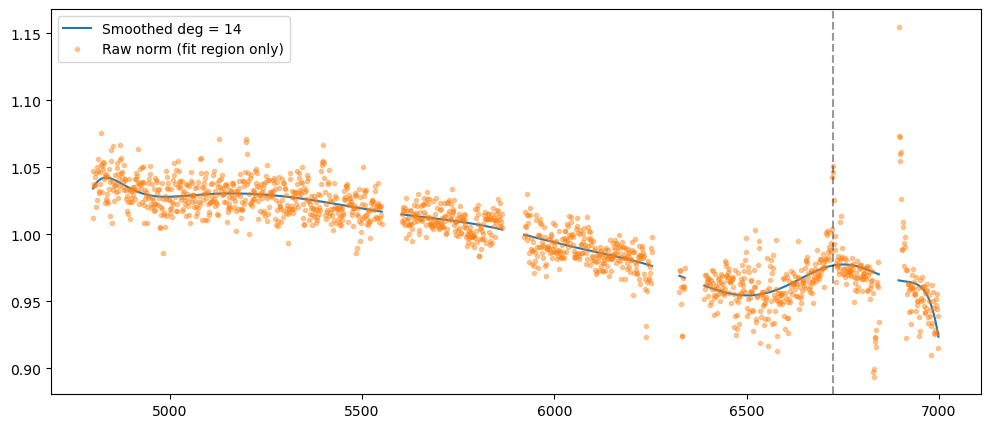

In [68]:
# ---------------- Load + interpolate model ----------------
wl_obs, flux_obs, flux_err = fitter._preprocess_observed_spectrum(
    spectra[0],
    [4700, 7000],
    atmospheric_lines=atmospheric_lines
)

interp_model = interp1d(
    best_model_spec.wl, best_model_spec.flux,
    kind='linear',
    bounds_error=False,
    fill_value=np.nan
)
flux_model = interp_model(wl_obs)

# ---------------- 1) Buildp safe mask ----------------
mask = (
    np.isfinite(wl_obs)
    & np.isfinite(flux_obs)
    & np.isfinite(flux_model)
    & np.isfinite(flux_err)
    & (flux_err > 0)
    & (np.abs(flux_model) > 1e-30)
)

# Restrict fitting region (IMPORTANT!)
wl_fit_min, wl_fit_max = 4800, 7000
mask &= (wl_obs >= wl_fit_min) & (wl_obs <= wl_fit_max)

# Apply mask
wl = wl_obs[mask]
fo = flux_obs[mask]
fm = flux_model[mask]
err = flux_err[mask]

# ---------------- 2) Raw normalization factor ----------------
norm_raw = fo / fm

# ---------------- 3) Rescale wavelengths ----------------
wl_med = np.median(wl)
wl_span = wl.ptp() if wl.ptp() != 0 else 1.0
wl_scaled = (wl - wl_med) / wl_span

poly_deg = 14

# ---------------- 4) Fit polynomial WITHIN fitting region only ----------------
try:
    coeff = np.polyfit(wl_scaled, norm_raw, deg=poly_deg, w=1.0/err)

    # Prepare full array (filled with NaN)
    normalization_factor_smoothed = np.full_like(wl_obs, np.nan)

    # Only evaluate inside fitting mask
    wl_scaled_full = (wl_obs - wl_med) / wl_span
    normalization_factor_smoothed[mask] = np.polyval(coeff, wl_scaled_full[mask])

except np.linalg.LinAlgError:
    # fallback: constant normalization
    median_val = np.nanmedian(norm_raw)
    normalization_factor_smoothed = np.full_like(wl_obs, median_val)

# ---------------- 6) Plot ----------------
plt.figure(figsize=(12,5))

plt.plot(wl_obs, flux_obs, label='Observed')
plt.plot(wl_obs, flux_model, alpha=0.5, label='Model')
plt.axvline(x=6725,c='black',alpha=0.4,ls='--')


plt.figure(figsize=(12,5))
plt.plot(wl_obs, normalization_factor_smoothed, label=f'Smoothed deg = {poly_deg:.0f}')
plt.plot(wl, norm_raw, '.', alpha=0.4, label='Raw norm (fit region only)')

plt.axvline(6725,c='black',alpha=0.4,ls='--')

#plt.xlim(4500,9000)
#plt.xlim(6700,6750)
plt.legend()
plt.show()



(6500.0, 6750.0)

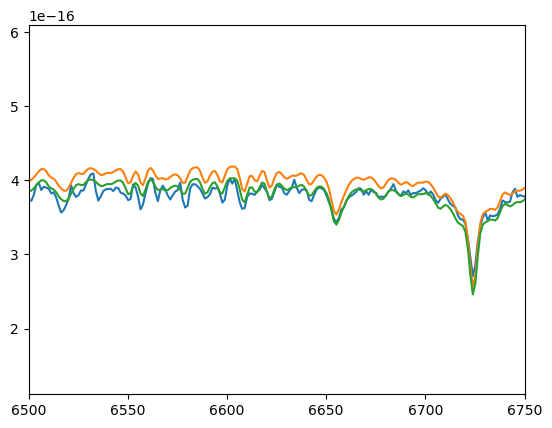

In [111]:
plt.plot(wl_obs,flux_obs)
plt.plot(wl_obs,flux_model)
plt.plot(wl_obs,flux_model*normalization_factor_smoothed)
plt.xlim(6500,6750)

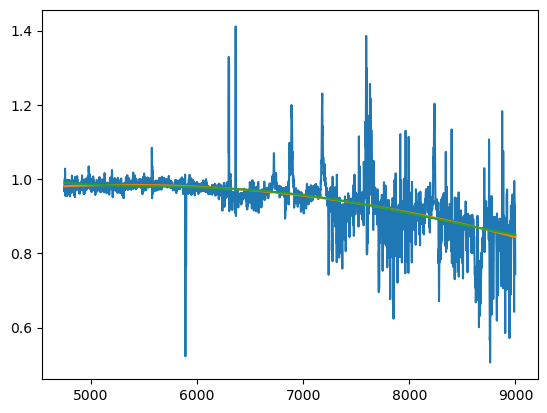

In [116]:
from pangal.data.spectral_lines import atmospheric_lines
from scipy.interpolate import interp1d

wl_obs,flux_obs,flux_err = fitter._preprocess_observed_spectrum(spectra[0],[4700,9000],atmospheric_lines={}) #atmospheric_lines

interp_model = interp1d(best_model_phot.wl, best_model_phot.flux,kind='linear', bounds_error=False, fill_value=np.nan)
flux_model = interp_model(wl_obs) 

normalization_factor = flux_obs / flux_model
plt.plot(wl_obs,normalization_factor)

coeff = np.polyfit(wl_obs, normalization_factor, deg=3,w=1./flux_err)
normalization_factor_smoothed = np.polyval(coeff, wl_obs)

plt.plot(wl_obs,normalization_factor_smoothed)


coeff = np.polyfit(wl_obs, normalization_factor, deg=4,w=1./flux_err)
normalization_factor_smoothed = np.polyval(coeff, wl_obs)

plt.plot(wl_obs,normalization_factor_smoothed)



(7000.0, 7200.0)

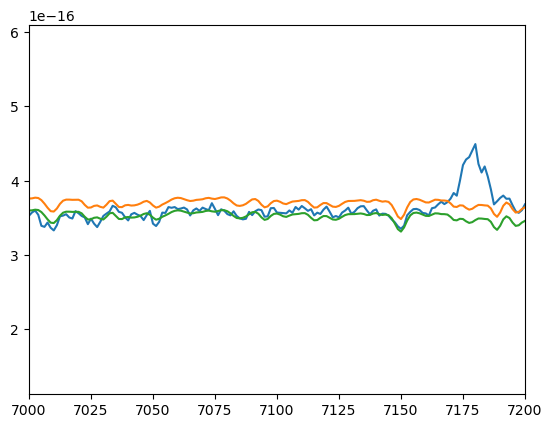

In [123]:
plt.plot(wl_obs,flux_obs)
plt.plot(wl_obs,flux_model)
plt.plot(wl_obs,flux_model*normalization_factor_smoothed)

plt.xlim(4900,5000)
plt.xlim(7000,7200)
#plt.xlim(6500,6750)

In [ ]:

    """
    
                # --- User-selected wavelength range for continuum fit ---
                #### FIX!!!!
                wl_fit_min, wl_fit_max = 4800, 7000   # example — you can replace with run.continuum_range


                # ---------------- 1) Build a safe mask for continuum fitting ----------------
                mask = (
                    np.isfinite(flux_model)
                    & np.isfinite(flux_obs)
                    & np.isfinite(err_obs)
                    & (err_obs > 0)
                    & (np.abs(flux_model) > 1e-30)
                )

                # *** Restrict mask to the wavelength fitting window ***
                mask &= (wl_obs >= wl_fit_max) & (wl_obs <= wl_fit_max)

                n_valid = mask.sum()


                # ---------------- 2) Determine polynomial degree ----------------
                if n_valid < max(10, run.polymax + 1):
                    poly_deg = max(1, min(run.polymax, n_valid - 1))
                else:
                    poly_deg = min(run.polymax, n_valid - 1)


                # ---------------- 3) Compute raw normalization factor ----------------
                normalization_factor = np.full_like(flux_obs, np.nan)
                normalization_factor[mask] = flux_obs[mask] / flux_model[mask]


                # ---------------- 4) Fit polynomial only on masked region ----------------
                if n_valid >= poly_deg + 1:

                    # weights
                    w = 1.0 / err_obs[mask]

                    # wavelength scaling for stability
                    wl_masked = wl_obs[mask]
                    wl_med = np.median(wl_masked)
                    wl_span = wl_masked.ptp() if wl_masked.ptp() != 0 else 1.0
                    wl_scaled = (wl_masked - wl_med) / wl_span

                    # polyfit
                    coeff = np.polyfit(wl_scaled, normalization_factor[mask], deg=poly_deg, w=w)

                    # evaluate across full wavelength range:
                    wl_scaled_full = (wl_obs - wl_med) / wl_span
                    normalization_factor_smoothed = np.polyval(coeff, wl_scaled_full)

                else:
                    # fallback: constant continuum
                    median_val = np.nanmedian(normalization_factor[mask])
                    normalization_factor_smoothed = np.full_like(wl_obs, median_val)


                # ---------------- 5) Scale the model ----------------
                model_scaled = flux_model * normalization_factor_smoothed

    
    """

In [31]:
wl = spectra[0].wl
wl_min = wl[0]
wl_max = wl[-1]

# Convert to indices
i_min = np.searchsorted(wl, wl_min)
i_max = np.searchsorted(wl, wl_max)

chi2 = np.sum(
    (best_model_phot.flux[i_min:i_max] - spectra[0].flux[i_min:i_max])**2
    / spectra[0].flux_err[i_min:i_max]**2
)

print(chi2)


47778973.53299931


In [32]:
wl = spectra[0].wl
wl_min = wl[0]
wl_max = wl[-1]

# Convert to indices
i_min = np.searchsorted(wl, wl_min)
i_max = np.searchsorted(wl, wl_max)

chi2 = np.sum(
    (best_model_spec.flux[i_min:i_max] - spectra[0].flux[i_min:i_max])**2
    / spectra[0].flux_err[i_min:i_max]**2
)

print(chi2)


28182993.64391815


In [55]:
47515874.38214057 / 27789393.312866386

1.709856485428953

(0.0, 10000.0)

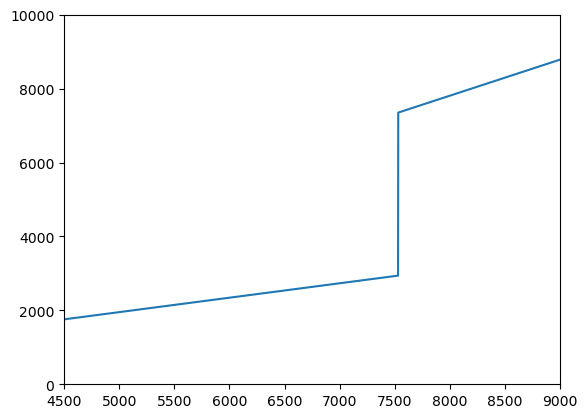

In [46]:
plt.plot(results_with_spec.best_model().wl,results_with_spec.best_model().resolution)
plt.xlim(4500,9000)
plt.ylim(0,10000)


(5550, 5600)

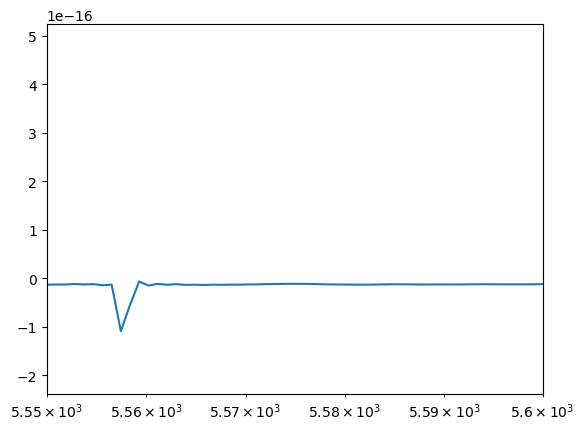

In [47]:
ww = results_with_spec.best_model().wl
fl = results_with_spec.best_model().flux

plt.plot(ww,fl-only_phot_spec.flux)
plt.xscale('log')
plt.xlim(5550,5600)



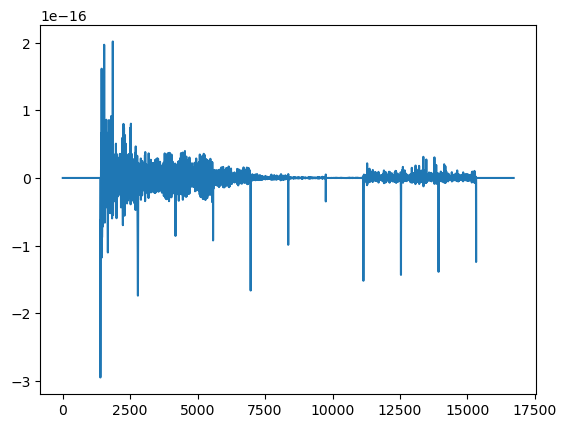

In [110]:
plt.plot(results_with_spec.best_model().flux - best_model_spec.flux)

In [63]:
ddd = {'a':1,'b':2}
for d in ddd:
    print(ddd[d])

1
2


In [33]:
hdr

WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =    173.4312520532751 / Systemic velocity [km/s]                       
SIGMA_V =    80.20787571857797 / LOS velocity dispersion [km/s]                 
AV      =  0.08620182380655526 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of ionizing photons            
ION_GAS =                -3.94 / Ionization parameter                           
AGE_GAS =                   13 / Nebular region age [Myr]                       
ALPHA   =   1.7084191813295138 / Dust heating parameter                         
MSTAR   =    9.336287609416031 / log10 Stellar mass [Msun]                      
DL_MPC  =                  1

In [39]:
other_synth_spec.header

WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =    173.4312520532751 / Systemic velocity [km/s]                       
SIGMA_V =    80.20787571857797 / LOS velocity dispersion [km/s]                 
AV      =  0.08620182380655526 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of ionizing photons            
ION_GAS =                -3.94 / Ionization parameter                           
AGE_GAS =                   13 / Nebular region age [Myr]                       
ALPHA   =   1.7084191813295138 / Dust heating parameter                         
MSTAR   =    9.336287609416031 / log10 Stellar mass [Msun]                      
DL_MPC  =                  1

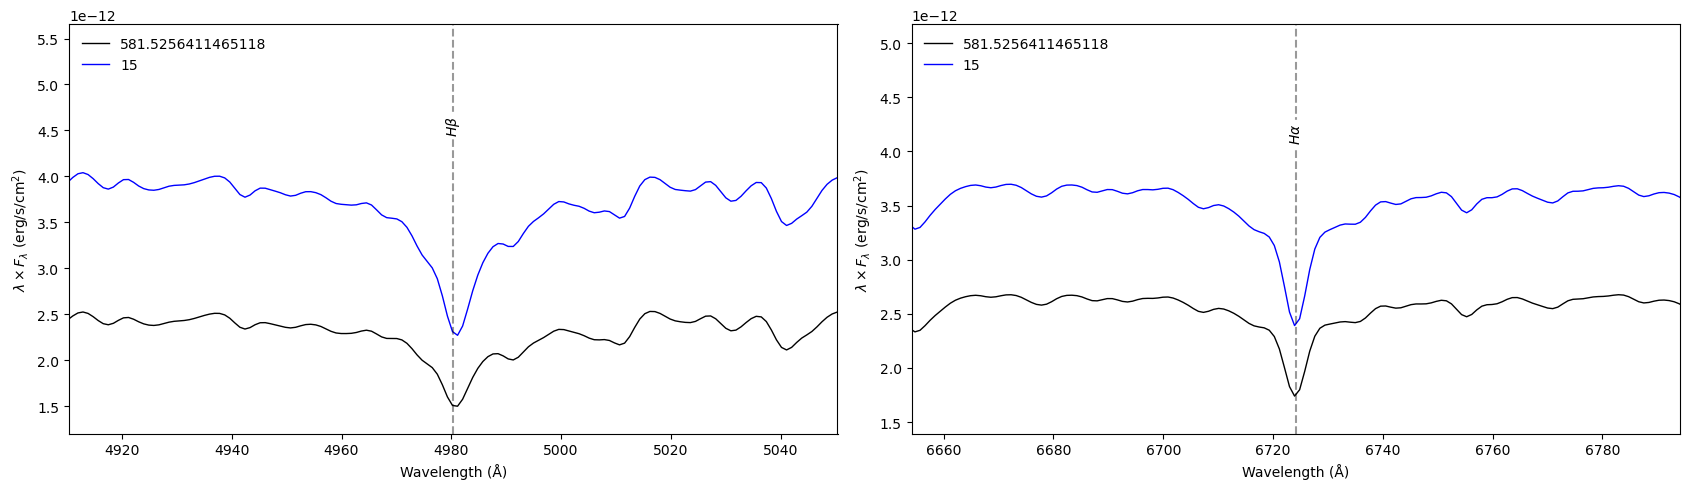

In [50]:
best_model = results_with_spec.best_model()
hdr = best_model.header
vel_sys   = hdr["vel_sys"]
sigma_vel = hdr["sigma_v"]
av        = hdr["av"]
av_ext    = hdr["av_ext"]
alpha     = hdr["alpha"]
fesc      = hdr["fesc"]
ion_gas   = hdr["ion_gas"]
age_gas   = hdr["age_gas"]
TAU_Q     = hdr["TAU_Q"]
BURST     = hdr["BURST"]
METAL     = hdr["METAL"]
m_star    = hdr["mstar"]
redshift  = hdr["redshift"]
luminosity_distance = hdr["dl_mpc"]

q_age = 15

other_synth_spec = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=Q_AGE,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)

results_with_spec.best_model().plot(figsize=(20,5), 
            #remove_continuum=True,
             spectra=[results_with_spec.best_model(),other_synth_spec], #spectra[0]
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Hb','Ha'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=1000,wsup=2e6,
            #winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars='Q_AGE',
            #show_phot_legend=False,
            show_spec_legend=True,
            ecolor='gray',
            color=['black','blue','green'],
           )



In [15]:
from pangal.run import Run
results_only_phot = Run().load('DATA/Coma/NGC4848/dynesty_Results/reg_1_only_phot_burst_metal_fixed.npz')
results_only_phot.pfitter = fitter
results_with_spec = Run().load('DATA/Coma/NGC4848/dynesty_Results/reg_1_spec_noburst.npz')
results_with_spec.pfitter = fitter

['Q_AGE', 'TAU_Q', 'av', 'alpha', 'm_star']
{'ion_gas': -3.94, 'age_gas': 13, 'fesc': 1.0, 'av_ext': 0, 'redshift': 0.023974, 'luminosity_distance': 100, 'BURST': 0, 'METAL': 0.017, 'vel_sys': None, 'sigma_vel': None}
<pangal.run.Run.load.<locals>.Result object at 0x74a10124f150>
Loaded fit results from DATA/Coma/NGC4848/dynesty_Results/reg_1_only_phot_burst_metal_fixed.npz
['Q_AGE', 'TAU_Q', 'BURST', 'METAL', 'av', 'alpha', 'm_star', 'vel_sys', 'sigma_vel']
{'ion_gas': -3.94, 'age_gas': 13, 'fesc': 1.0, 'av_ext': 0, 'redshift': 0.023974, 'luminosity_distance': 100}
<pangal.run.Run.load.<locals>.Result object at 0x74a10124dfd0>
Loaded fit results from DATA/Coma/NGC4848/dynesty_Results/reg_1_spec_noburst.npz


In [16]:
results_only_phot.best_model().header

WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =  / Systemic velocity [km/s]                                           
SIGMA_V =  / LOS velocity dispersion [km/s]                                     
AV      =   0.0969952316885166 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of ionizing photons            
ION_GAS =                -3.94 / Ionization parameter                           
AGE_GAS =                   13 / Nebular region age [Myr]                       
ALPHA   =   1.7751552099909125 / Dust heating parameter                         
MSTAR   =     9.30036249146218 / log10 Stellar mass [Msun]                      
DL_MPC  =                  1

In [17]:
results_with_spec.best_model().header

WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =    173.8376609359176 / Systemic velocity [km/s]                       
SIGMA_V =    79.04352978040788 / LOS velocity dispersion [km/s]                 
AV      =  0.07826188210144801 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of ionizing photons            
ION_GAS =                -3.94 / Ionization parameter                           
AGE_GAS =                   13 / Nebular region age [Myr]                       
ALPHA   =   1.8153505957970324 / Dust heating parameter                         
MSTAR   =    9.354443339435852 / log10 Stellar mass [Msun]                      
DL_MPC  =                  1

In [12]:
spec_1 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=1,m_star=9.2994,
                                Q_AGE=15,TAU_Q=460.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)
                              

spec_2 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=13,m_star=9.2994,
                                Q_AGE=880.435,TAU_Q=460.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)
                              

In [28]:
hdr = results_only_phot.best_model().header

only_phot_corrected_z = fitter.synthetic_spectrum(
    # excluded on purpose:
    # vel_sys=..., 
    # sigma_vel=...,

    av       = hdr["AV"],
    av_ext   = hdr["AV_EXT"],
    alpha    = hdr["ALPHA"],
    fesc     = hdr["FESC"],
    ion_gas  = hdr["ION_GAS"],
    age_gas  = hdr["AGE_GAS"],
    m_star   = hdr["MSTAR"],
    Q_AGE    = hdr["Q_AGE"],
    TAU_Q    = hdr["TAU_Q"],
    BURST    = hdr["BURST"],
    METAL    = hdr["METAL"],
    
    redshift            = hdr["REDSHIFT"],
    luminosity_distance = hdr["DL_MPC"],   # the header says Mpc even though the key is DL_PC
    vel_sys=173.7456,
    sigma_vel=0.5*80.447
)

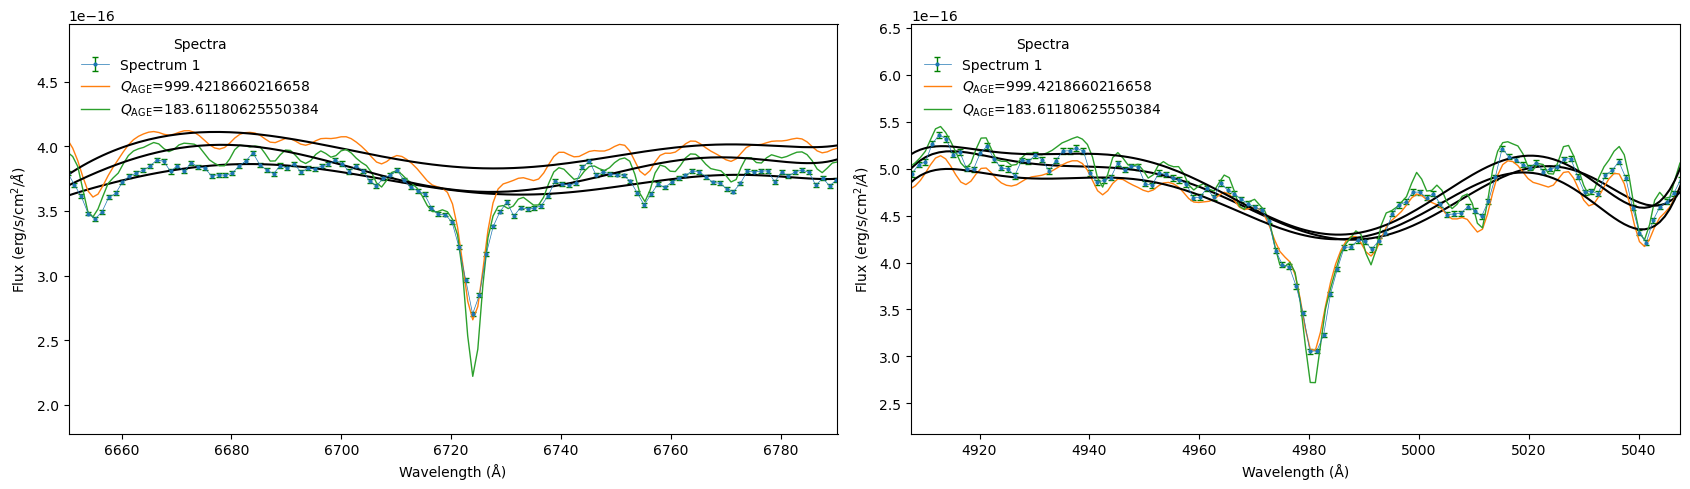

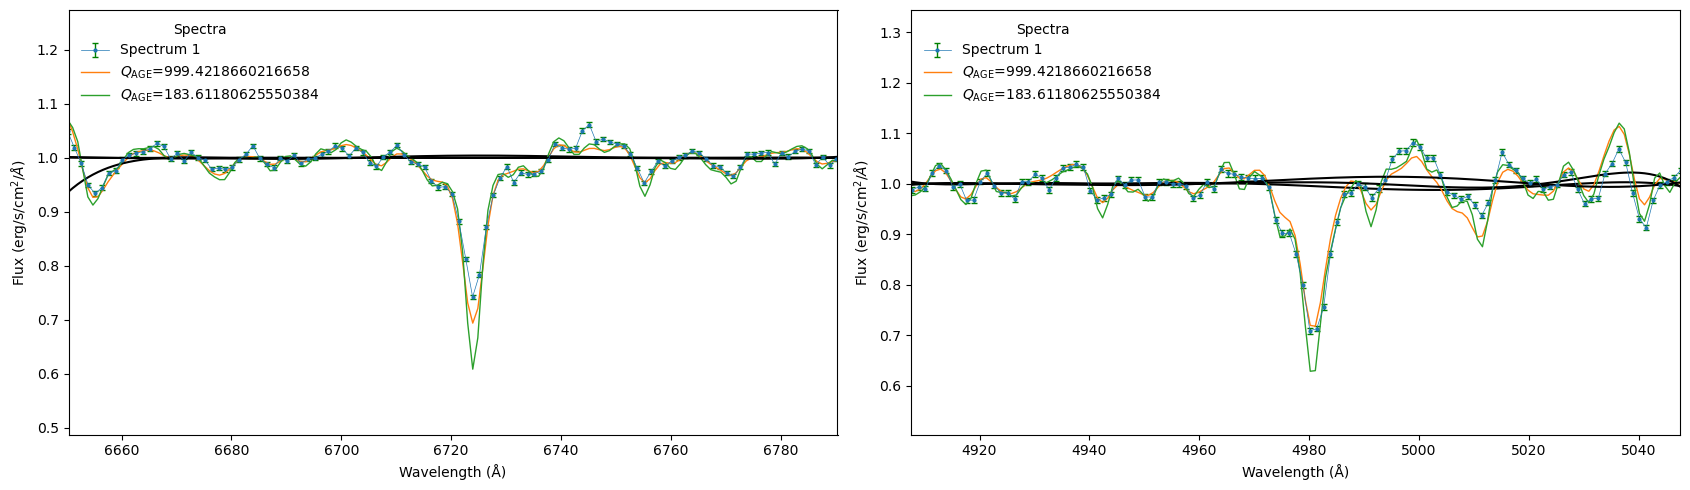

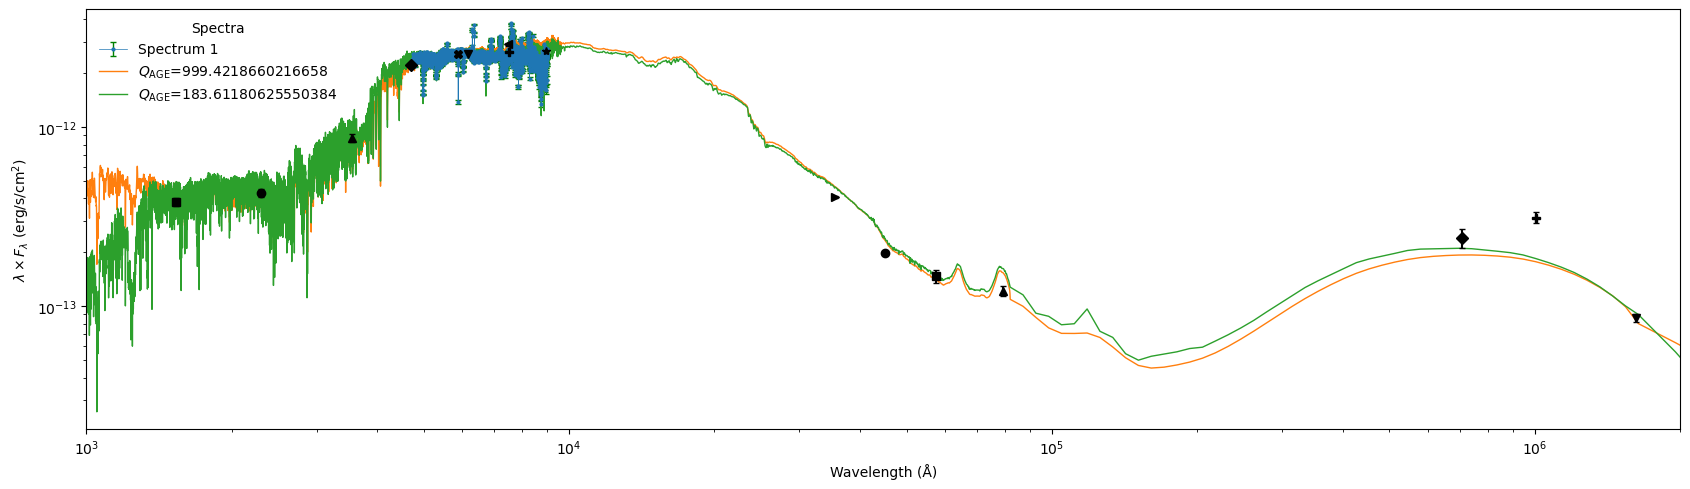

In [29]:
#legend = {'Q_AGE':'$Q_\\text{AGE}$'}
legend = {'Q_AGE':'$Q_\\text{AGE}$'}

#spec_1,spec_2


results_with_spec.best_model().plot(figsize=(20,5), 
            #remove_continuum=True,
              draw_continuum=True,                      
             spectra=[spec_0,results_with_spec.best_model(),only_phot_corrected_z],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

results_with_spec.best_model().plot(figsize=(20,5), 
            remove_continuum=True,
             draw_continuum=True,                       
             spectra=[spec_0,results_with_spec.best_model(),only_phot_corrected_z],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

results_with_spec.best_model().plot(figsize=(20,5), 
            #remove_continuum=True,
             spectra=[spec_0,results_with_spec.best_model(),only_phot_corrected_z],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=1000,wsup=2e6,
            #winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )
 

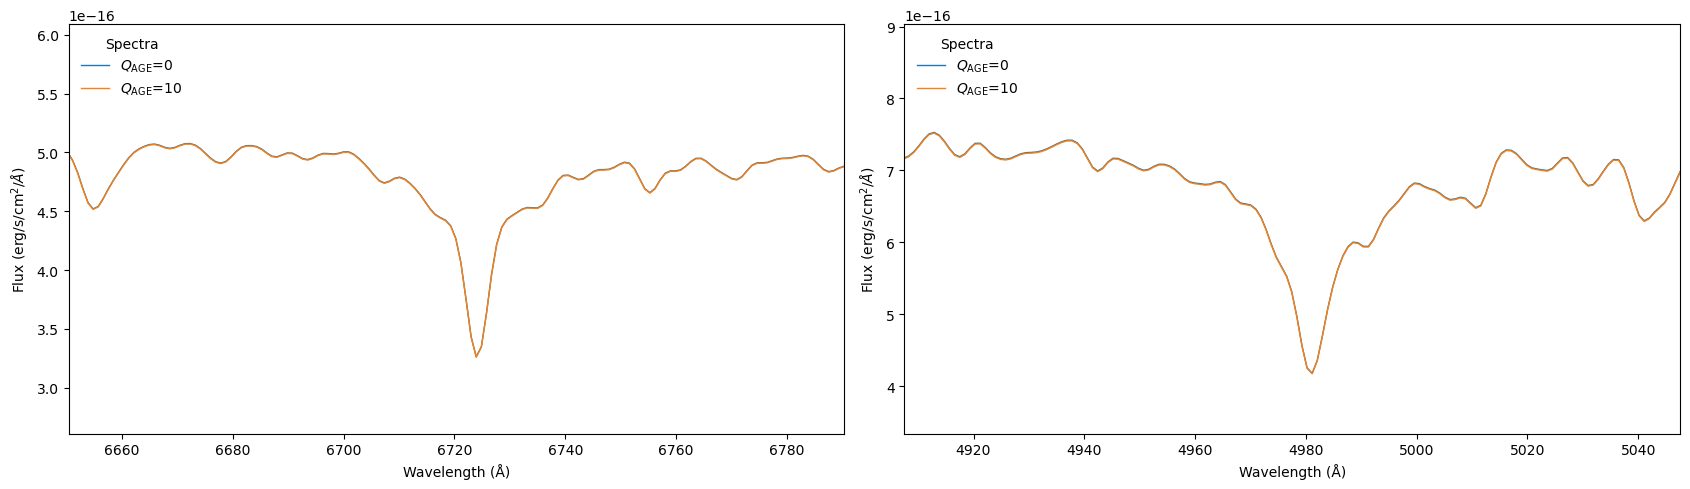

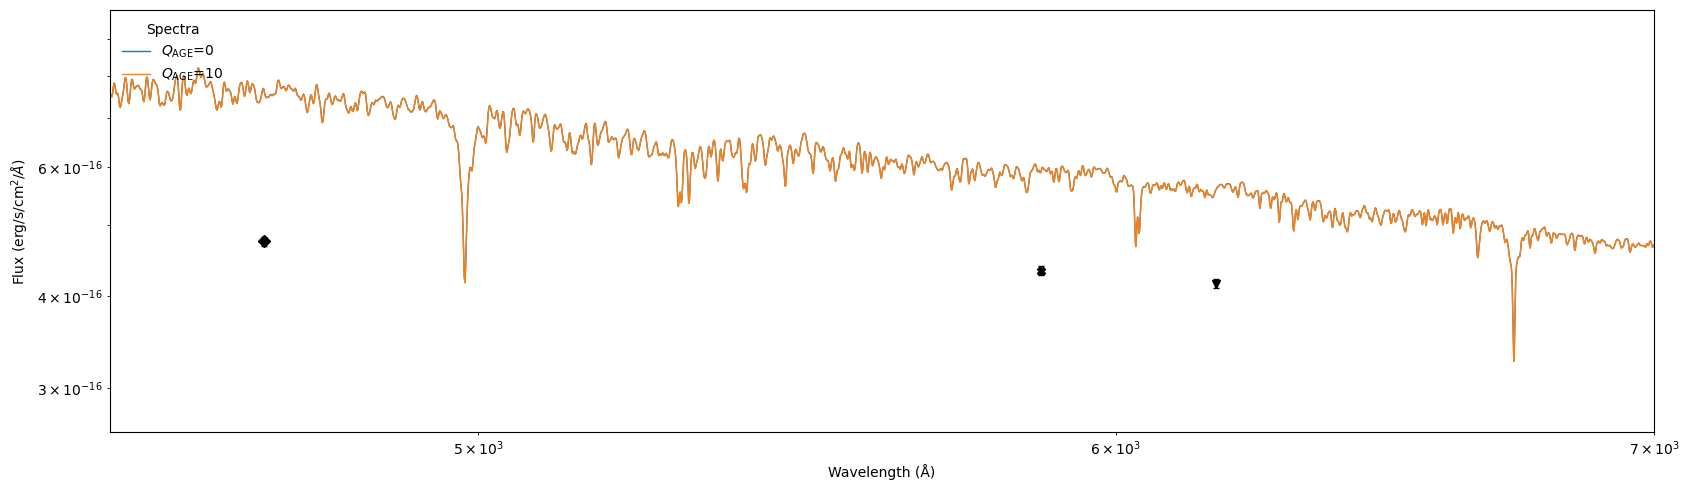

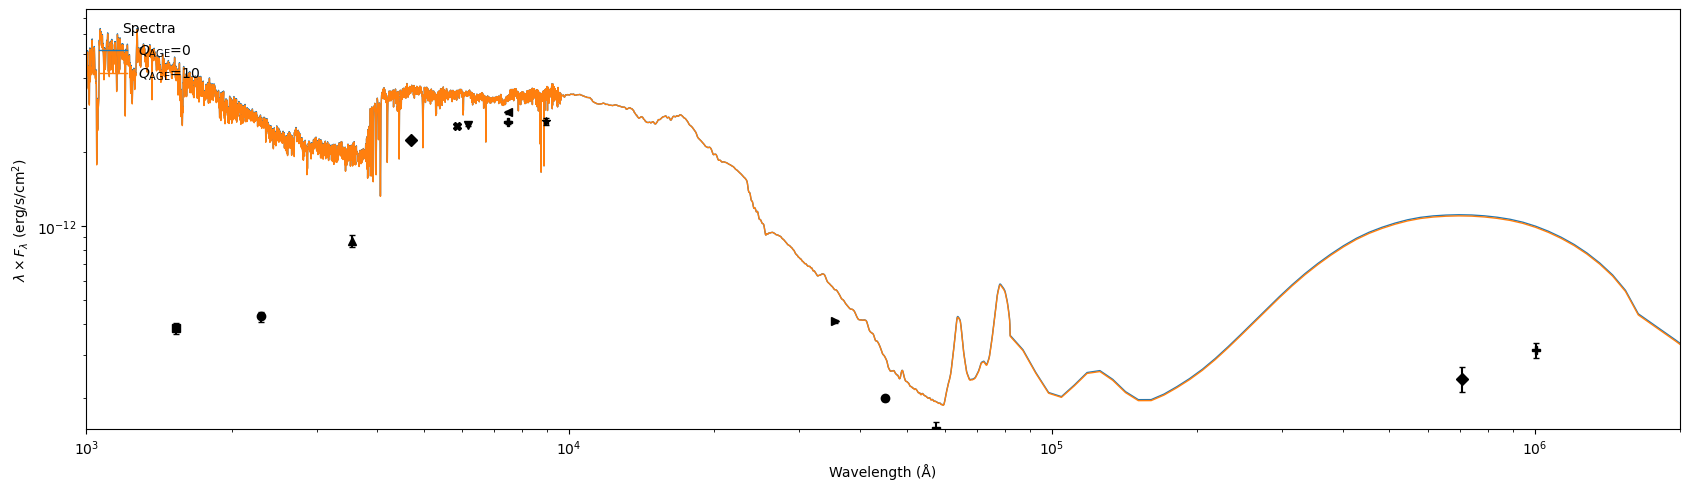

In [77]:
spec_1 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=1,m_star=9.2994,
                                Q_AGE=0,TAU_Q=460.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)

spec_1_5 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=13,m_star=9.2994,
                                Q_AGE=10,TAU_Q=460.1111,
                               BURST=0,METAL=0.008,redshift=0.023974,luminosity_distance=100)

legend = {'Q_AGE':'$Q_\\text{AGE}$'}

#spec_1,spec_2

spec_1.plot(figsize=(20,5), 
            #remove_continuum=True,
              #draw_continuum=True,                      
             spectra=[spec_1,spec_1_5,],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            zoom_on_line=['Ha','Hb'],
            spec_legend=legend,
            show_phot_legend=False,
           )

spec_1.plot(figsize=(20,5), 
            #remove_continuum=True,
              #draw_continuum=True,                      
             spectra=[spec_1,spec_1_5,],#spec_2,spec_3,spec_4],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

spec_1.plot(figsize=(20,5), 
            #remove_continuum=True,
              #draw_continuum=True,                      
             spectra=[spec_1,spec_1_5,],#spec_2,spec_3,spec_4],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )


In [71]:
results_only_phot.best_model().header
 

WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =  / Systemic velocity [km/s]                                           
SIGMA_V =  / LOS velocity dispersion [km/s]                                     
AV      =   0.0969952316885166 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of ionizing photons            
ION_GAS =                -3.94 / Ionization parameter                           
AGE_GAS =                   13 / Nebular region age [Myr]                       
ALPHA   =   1.7751552099909125 / Dust heating parameter                         
MSTAR   =     9.30036249146218 / log10 Stellar mass [Msun]                      
DL_MPC  =                  1

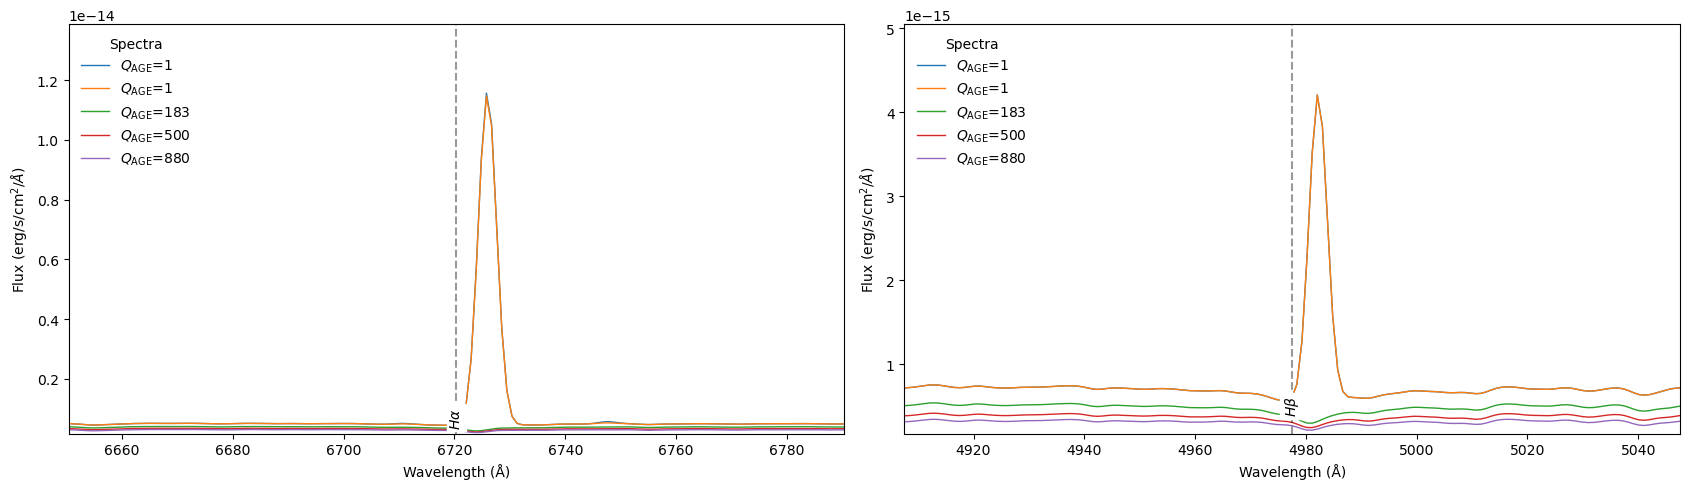

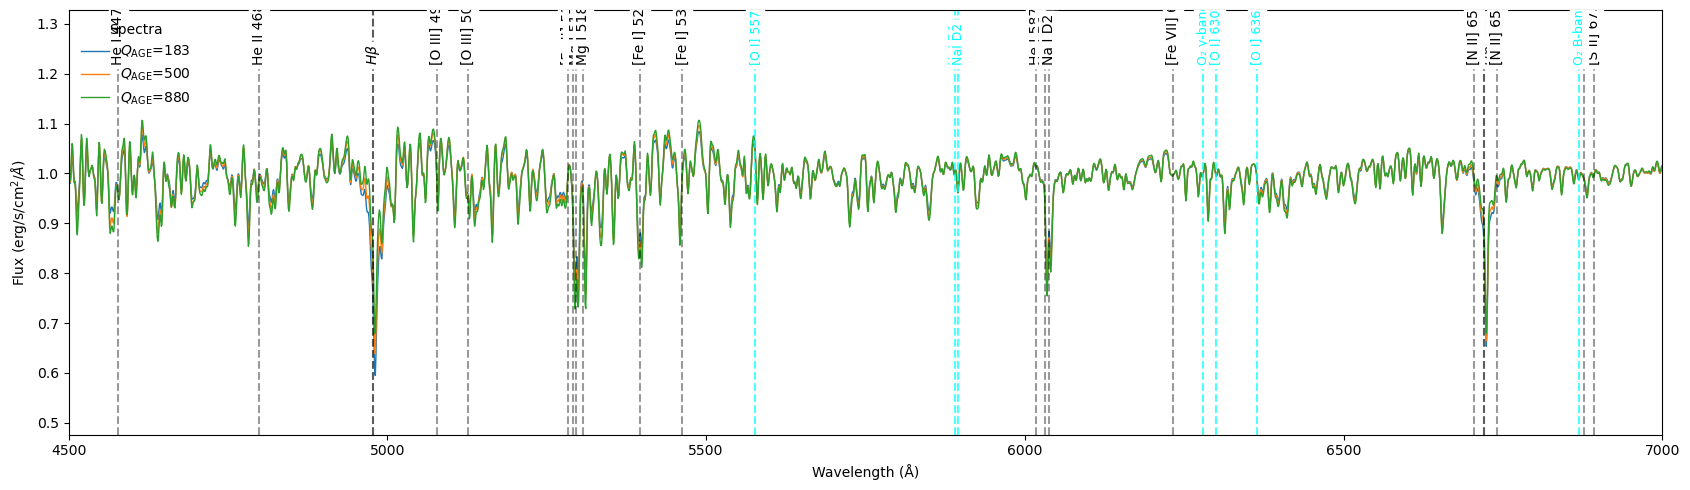

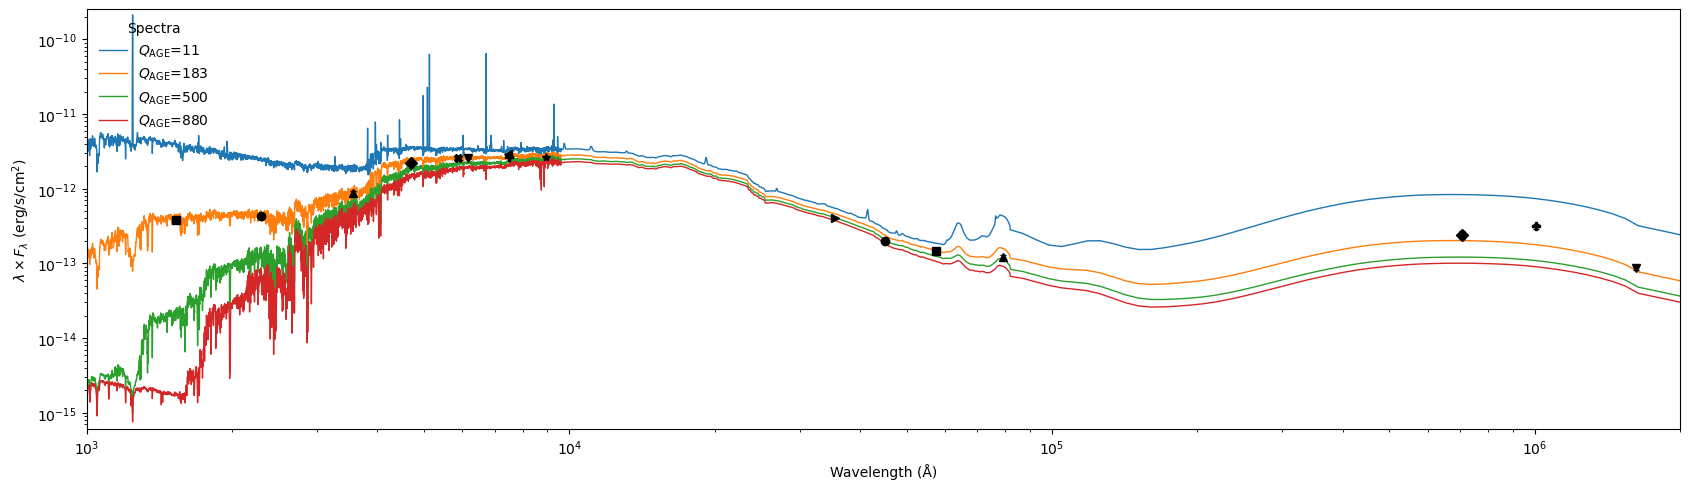

In [99]:
spec_0 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,
                                av=0.0939,av_ext=0,alpha=1.775,
                               fesc=0.1,ion_gas=-2.0,age_gas=1,m_star=9.30,
                                Q_AGE=1,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)
spec_0_age = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,
                                av=0.0939,av_ext=0,alpha=1.775,
                               fesc=0.1,ion_gas=-1.0,age_gas=1,m_star=9.30,
                                Q_AGE=1,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)
spec_00 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,
                                av=0.0939,av_ext=0,alpha=1.775,
                               fesc=0.1,ion_gas=-2.0,age_gas=1,m_star=9.30,
                                Q_AGE=11,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)



spec_1 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,
                                av=0.0939,av_ext=0,alpha=1.775,
                               fesc=1,ion_gas=-3.94,age_gas=30,m_star=9.30,
                                Q_AGE=183,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)

spec_2 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=13,m_star=9.2994,
                                Q_AGE=500,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)
                              

spec_3 = fitter.synthetic_spectrum(
                               vel_sys=173.7456,sigma_vel=80.447,av=0.0939,av_ext=0,alpha=1.7931,
                               fesc=1,ion_gas=-3.94,age_gas=13,m_star=9.2994,
                                Q_AGE=880,TAU_Q=46.1111,
                               BURST=0,METAL=0.017,redshift=0.023974,luminosity_distance=100)


spec_1.plot(figsize=(20,5), 
            #remove_continuum=True,
              #draw_continuum=True,                      
             spectra=[spec_0,spec_0_age,spec_1,spec_2,spec_3],#spec_2,spec_3,spec_4],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Ha','Hb'],
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

spec_1.plot(figsize=(20,5), 
            remove_continuum=True,
              #draw_continuum=True,                      
             spectra=[spec_1,spec_2,spec_3],#spec_2,spec_3,spec_4], spec_0,spec_00,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

spec_1.plot(figsize=(20,5), 
            #remove_continuum=True,
            #draw_continuum=True,                      
             spectra=[spec_00,spec_1,spec_2,spec_3],
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', 
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )



In [100]:
results_with_spec_noburst.best_model()

Spectrum(wl=array([5.73757761e+00, 6.65968841e+00, 7.58179921e+00, ...,
       1.38654264e+09, 1.78621296e+09, 2.30108787e+09]), resolution=array([2.80e+00, 3.25e+00, 3.70e+00, ..., 8.00e+05, 8.00e+05, 8.00e+05],
      dtype=float32), flux=array([ 4.05127462e-25, -4.06340767e-25,  4.07560247e-25, ...,
        1.08954937e-23,  1.00873335e-23,  7.23889661e-24]), flux_err=None, header=WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =   173.74565677420674 / Systemic velocity [km/s]                       
SIGMA_V =    80.44700056683291 / LOS velocity dispersion [km/s]                 
AV      =  0.08617853888503252 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction

In [101]:
results_with_spec.save('DATA/Coma/NGC4848/dynesty_Results/reg_1_spec_noburst.npz')

Saved fit results to DATA/Coma/NGC4848/dynesty_Results/reg_1_spec_noburst.npz


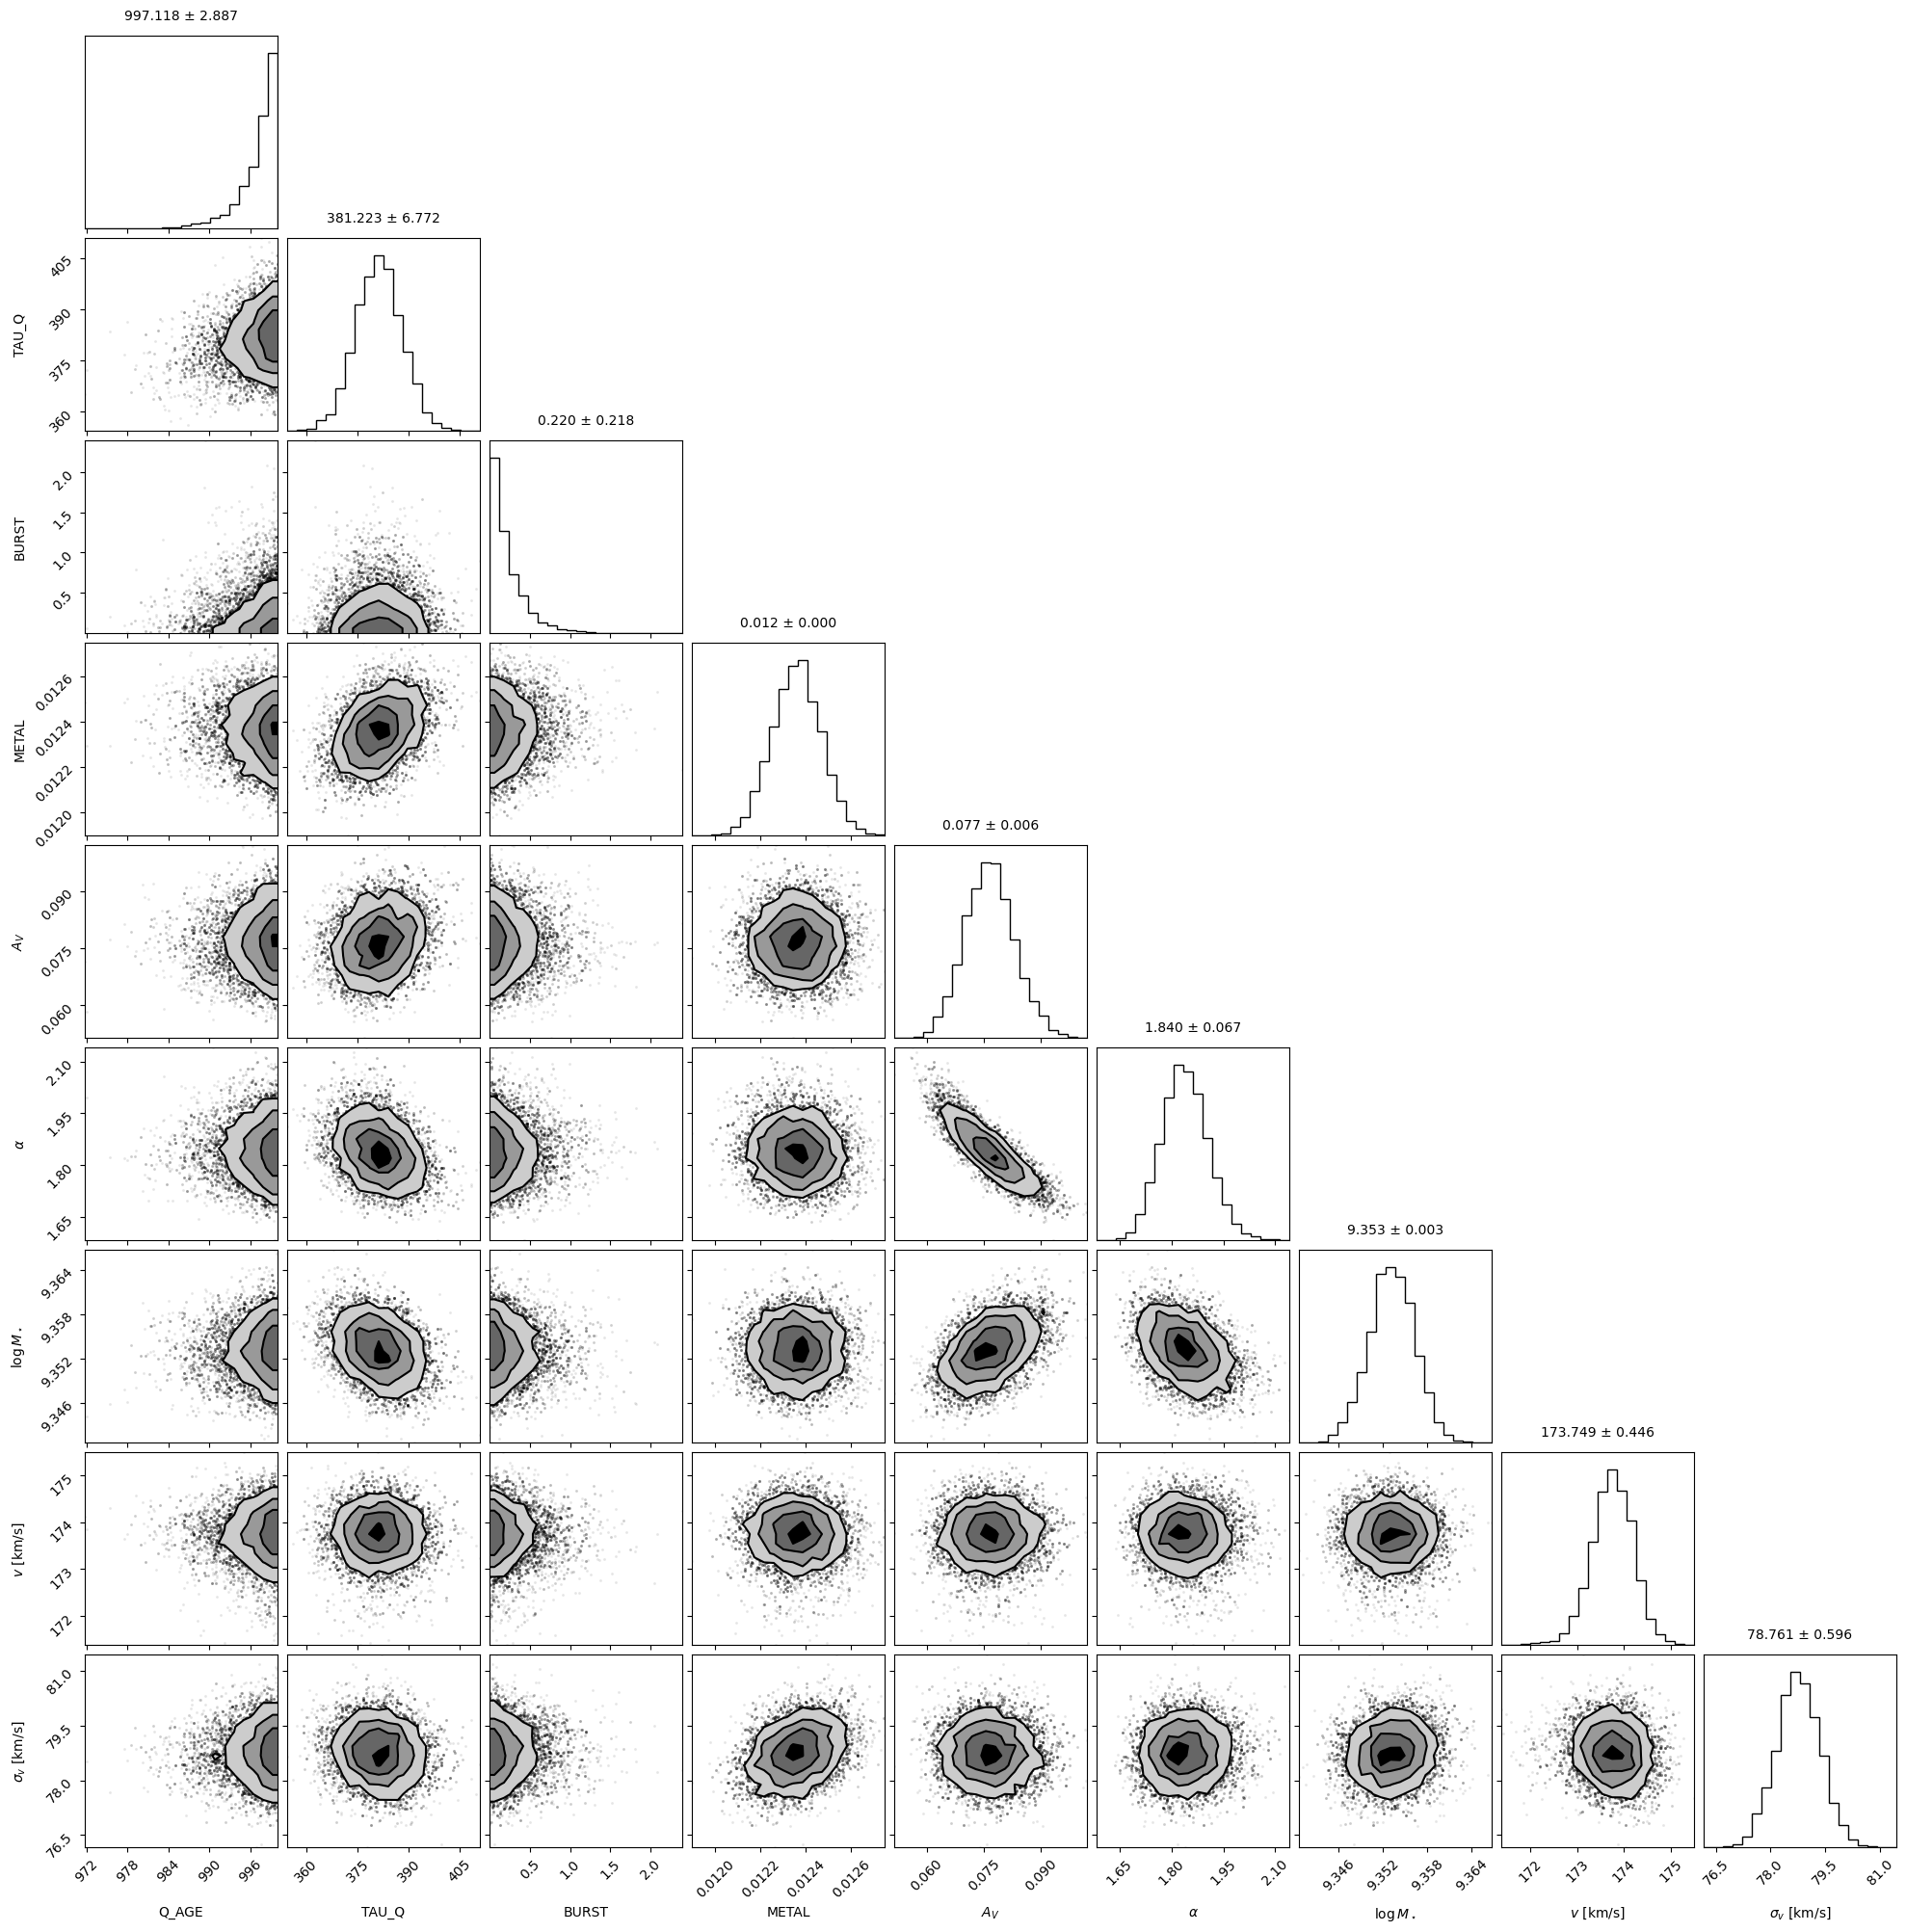

In [76]:
results_with_spec.cornerplot()

In [78]:
best_sp = results_with_spec.best_model()

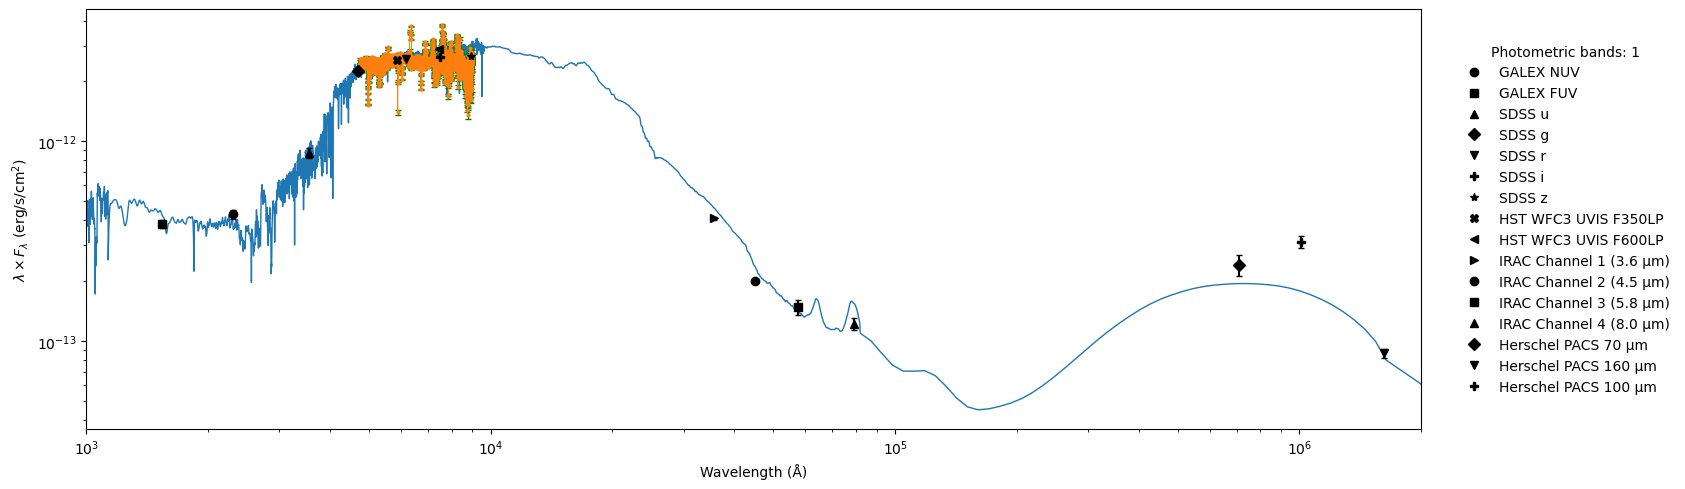

In [95]:
best_sp.plot(figsize=(20,5), 
            #remove_continuum=True,
             spectra=[best_sp,spectra[0]],
            #normalized=True,
            per_wavelength=True, 
            phot_points=phot_list, phot_region='1', show_spec_legend=False,
            
            #show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
           )
 

In [37]:
sp = rrr.top_synthetic_spectra(n=10)

In [41]:
rrr.best_model()

(Spectrum(wl=array([5.73425430e+00, 6.65583100e+00, 7.57740770e+00, ...,
        1.38573953e+09, 1.78517835e+09, 2.29975504e+09]), resolution=array([2.80e+00, 3.25e+00, 3.70e+00, ..., 8.00e+05, 8.00e+05, 8.00e+05],
       dtype=float32), flux=array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.36763058e-23, 1.36763058e-23, 1.36763058e-23]), flux_err=None, header=WUNITS  = 'A       '                                                            
 FUNITS  = 'erg/s/cm2/A'                                                         
 REDSHIFT=             0.023974 / Cosmological redshift                          
 VEL_SYS =  / Systemic velocity [km/s]                                           
 SIGMA_V =  / LOS velocity dispersion [km/s]                                     
 AV      =  0.10589217008546821 / V-band attenuation (old stars)                 
 AV_EXT  =                    0 / Extra attenuation (young stars)                
 FESC    =                  1.0 / Escape fra

In [40]:
sp[0]


Spectrum(wl=array([5.73425430e+00, 6.65583100e+00, 7.57740770e+00, ...,
       1.38573953e+09, 1.78517835e+09, 2.29975504e+09]), resolution=array([2.80e+00, 3.25e+00, 3.70e+00, ..., 8.00e+05, 8.00e+05, 8.00e+05],
      dtype=float32), flux=array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.36763058e-23, 1.36763058e-23, 1.36763058e-23]), flux_err=None, header=WUNITS  = 'A       '                                                            
FUNITS  = 'erg/s/cm2/A'                                                         
REDSHIFT=             0.023974 / Cosmological redshift                          
VEL_SYS =  / Systemic velocity [km/s]                                           
SIGMA_V =  / LOS velocity dispersion [km/s]                                     
AV      =  0.10589217008546821 / V-band attenuation (old stars)                 
AV_EXT  =                    0 / Extra attenuation (young stars)                
FESC    =                  1.0 / Escape fraction of io

In [58]:
from pangal.run import Run
rrr = Run()
rrr.load('DATA/Coma/NGC4848/dynesty_Results/reg_1_only_phot_burst_metal_fixed.npz')
rrr.pfitter = fitter

['Q_AGE', 'TAU_Q', 'av', 'alpha', 'm_star']
{'ion_gas': -3.94, 'age_gas': 13, 'fesc': 1.0, 'av_ext': 0, 'redshift': 0.023974, 'luminosity_distance': 100, 'BURST': 0, 'METAL': 0.017, 'vel_sys': None, 'sigma_vel': None}
<pangal.run.Run.load.<locals>.Result object at 0x700ba1d0cad0>
Loaded fit results from DATA/Coma/NGC4848/dynesty_Results/reg_1_only_phot_burst_metal_fixed.npz


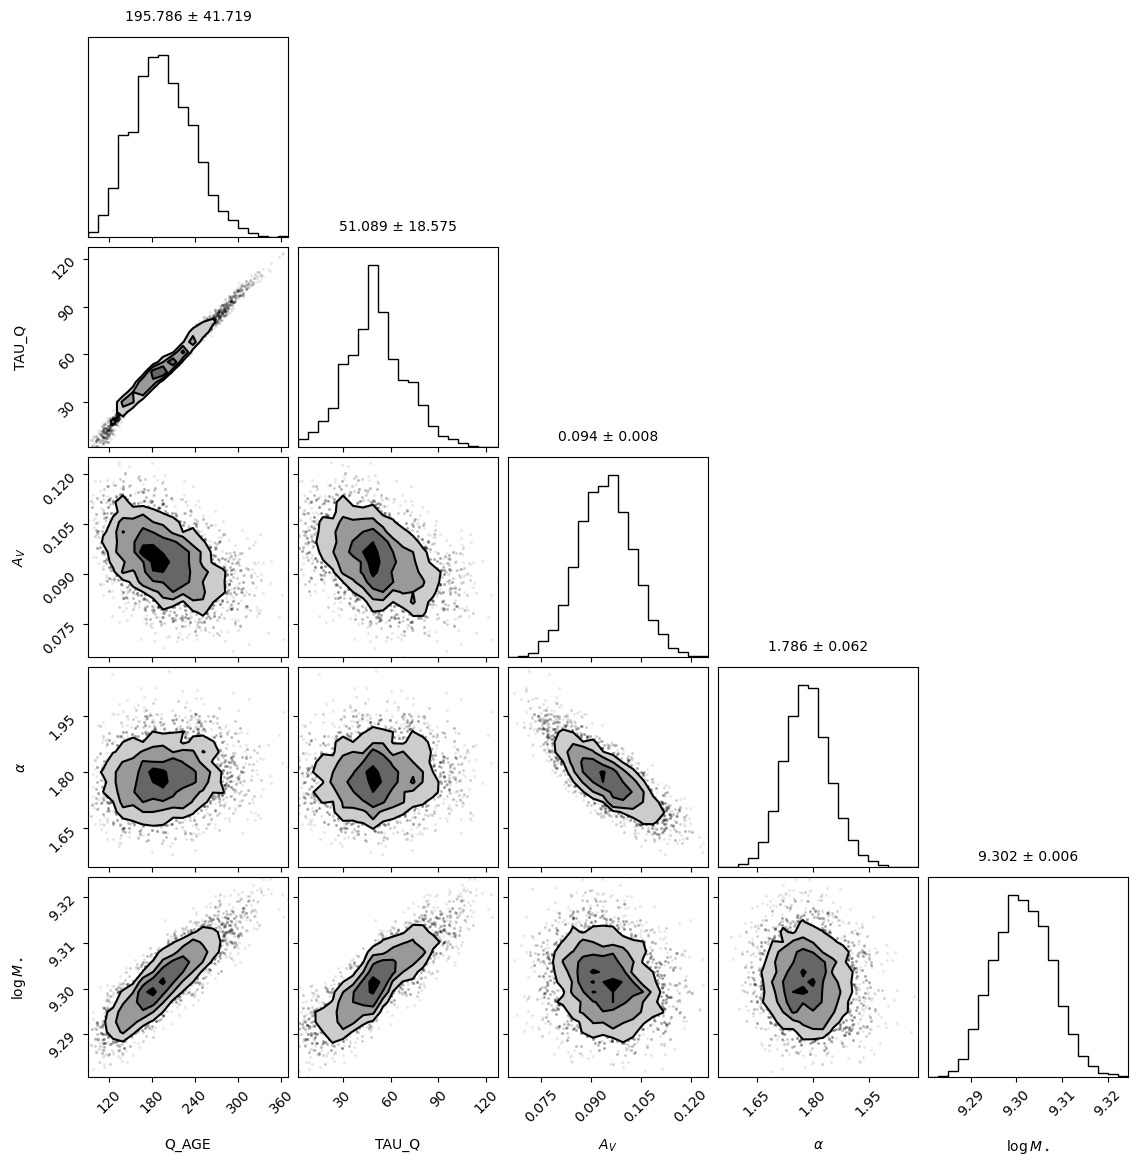

In [59]:
rrr.cornerplot()

In [15]:
data = np.load('only_phot_test.npz', allow_pickle=True)
print(data.files)
print(data['fitter_classes'])


['samples', 'logl', 'logwt', 'logz', 'free_pars', 'fix_pars', 'custom_priors', 'spectral_range', 'nlive', 'dlogz', 'polymax', 'wl_obs', 'flux_obs_norm', 'err_obs_norm', 'obs_resolution_on_model_grid', 'phot', 'bands', 'fitter_class', 'fitter_args']


KeyError: 'fitter_classes is not a file in the archive'

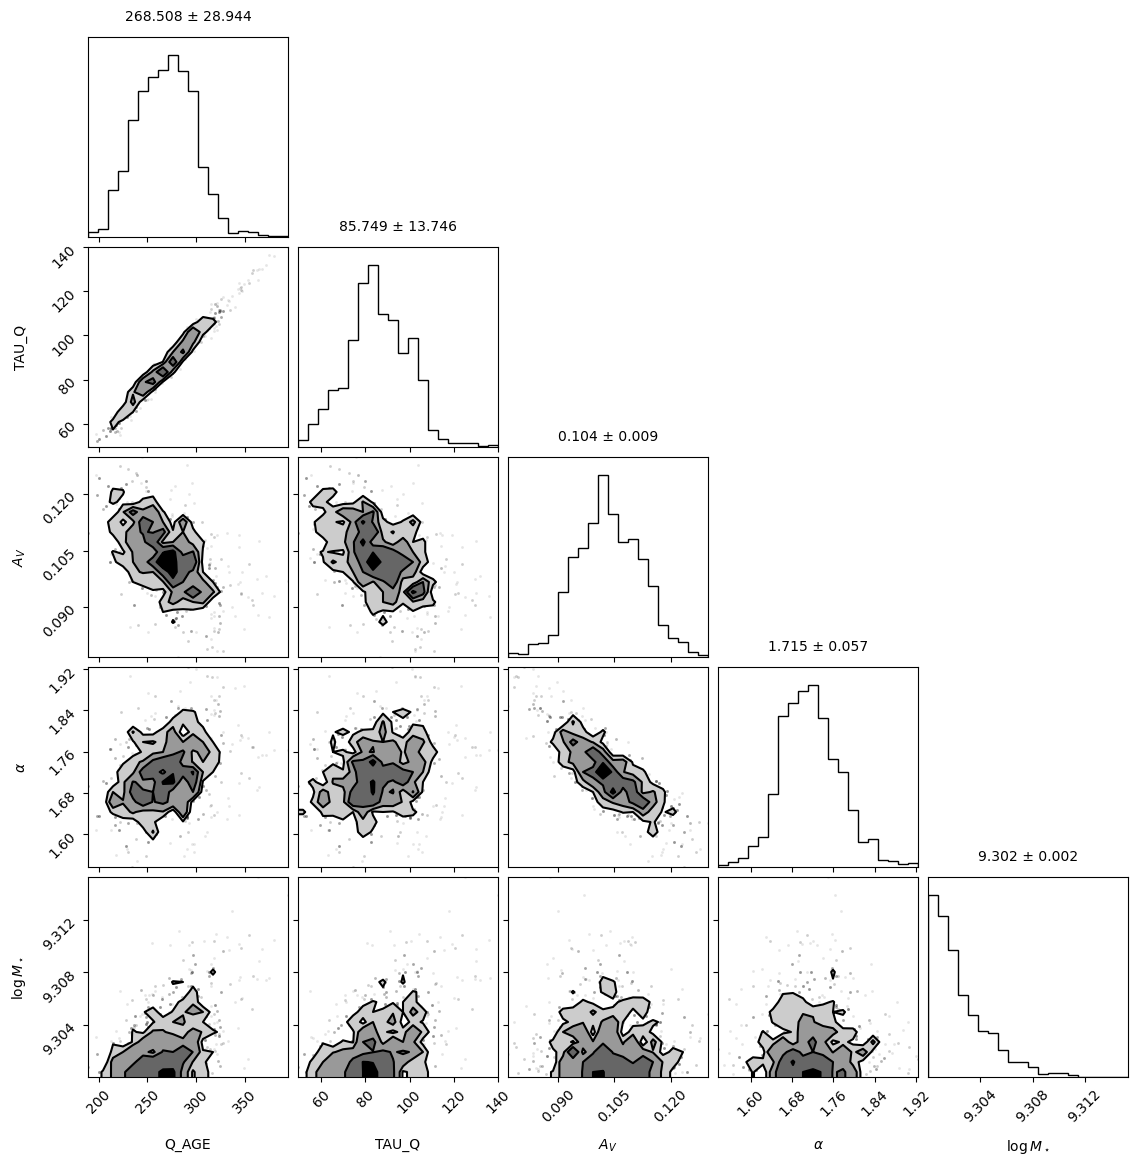

In [12]:
results_only_phot.cornerplot(cmap='jet')

In [27]:
rrr.best_model()
#results_only_phot.best_model()

(Spectrum(wl=array([5.73425430e+00, 6.65583100e+00, 7.57740770e+00, ...,
        1.38573953e+09, 1.78517835e+09, 2.29975504e+09]), resolution=array([2.80e+00, 3.25e+00, 3.70e+00, ..., 8.00e+05, 8.00e+05, 8.00e+05],
       dtype=float32), flux=array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.36763058e-23, 1.36763058e-23, 1.36763058e-23]), flux_err=None, header=WUNITS  = 'A       '                                                            
 FUNITS  = 'erg/s/cm2/A'                                                         
 REDSHIFT=             0.023974 / Cosmological redshift                          
 VEL_SYS =  / Systemic velocity [km/s]                                           
 SIGMA_V =  / LOS velocity dispersion [km/s]                                     
 AV      =  0.10589217008546821 / V-band attenuation (old stars)                 
 AV_EXT  =                    0 / Extra attenuation (young stars)                
 FESC    =                  1.0 / Escape fra

In [ ]:
rrr.